# 平成26年度 市民の社会貢献に関する実態調査 分析レポート

| 項目 | 内容 |
|------|------|
| **出典** | 内閣府「平成26年度 市民の社会貢献に関する実態調査」集計結果 |
| **調査対象** | 日本全国の市民（20歳以上） |
| **有効回答数** | 約 1,647名 |
| **データ範囲** | 本ファイル収録：図表 2-29〜2-83（ボランティア活動関連クロス集計） |
| **注記** | 基本単純集計（2-1〜2-28）および寄附・NPO詳細（2-84〜2-162）は別ファイル |

---


## 0. セットアップ

In [1]:
import japanize_matplotlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', '{:.1f}'.format)

plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

EXCEL_PATH = "data/rr.xlsx"

# カラーパレット
C_INTEREST = ['#1A237E', '#5C6BC0', '#EF9A9A', '#B71C1C']   # 関心 強→弱
C_EXP      = ['#1565C0', '#BDBDBD']                          # 経験あり/なし
C_SET2     = sns.color_palette("Set2", 12)
C_BLUES    = sns.color_palette("Blues_r", 10)

print("セットアップ完了")


セットアップ完了


## 1. データ読み込み・描画ユーティリティ

In [2]:
\
# ─────────────────────────────
# データローダー
# ─────────────────────────────
def load_sheet(sheet_name):
    '''シートを読み込み (DataFrame, title) を返す。
    構造: 行0=タイトル, 行1=単位, 行2=回答選択肢ラベル, 行3+=データ行
    '''
    df_raw = pd.read_excel(EXCEL_PATH, sheet_name=sheet_name, header=None)

    # タイトル取得（行0の非NaN値を結合）
    title_parts = [str(v).strip() for v in df_raw.iloc[0]
                   if str(v).strip() not in ('nan', '')]
    title = ' '.join(title_parts) if title_parts else sheet_name

    # ヘッダー行を探す（行1以降で文字列 ≥2 の最初の行）
    header_row_idx, col_label_positions = None, []
    for i in range(1, min(8, len(df_raw))):
        row = df_raw.iloc[i]
        candidates = [(j, str(v).strip()) for j, v in enumerate(row)
                      if pd.notna(v) and isinstance(v, str)
                      and str(v).strip() not in ('', 'nan', '（単位：％）', '（単位：%）')]
        if len(candidates) >= 2:
            header_row_idx, col_label_positions = i, candidates
            break

    if header_row_idx is None:
        return None, title

    # データ行取得
    records = []
    for i in range(header_row_idx + 1, len(df_raw)):
        row = df_raw.iloc[i]
        group_raw = row.iloc[1] if len(row) > 1 else np.nan
        if pd.isna(group_raw) or str(group_raw).strip() in ('', 'nan'):
            continue
        group_str = str(group_raw).strip()
        n_match = re.search(r'n=([0-9,]+)', group_str)
        n = int(n_match.group(1).replace(',', '')) if n_match else None
        label = group_str.split('\n')[0].strip()
        label = re.sub(r'[\s　]*[（(]n=[0-9,]+[）)]', '', label).strip()
        row_data = {'グループ': label, 'n': n}
        for col_idx, col_name in col_label_positions:
            v = row.iloc[col_idx] if col_idx < len(row) else np.nan
            try:
                row_data[col_name] = float(v) if pd.notna(v) else np.nan
            except (ValueError, TypeError):
                row_data[col_name] = np.nan
        records.append(row_data)

    return (pd.DataFrame(records) if records else None), title


def dcols(df):
    # グループ・n以外のデータ列を返す
    return [c for c in df.columns if c not in ('グループ', 'n')]


def without_total(df):
    return df[df['グループ'] != '全体'].reset_index(drop=True)


# ─────────────────────────────
# 積み上げ横棒グラフ（単一・択一回答用）
# ─────────────────────────────
def plot_stacked(df, cols, title, colors, figsize=(13, 5),
                 exclude_total=True, value_thresh=4.0):
    data = without_total(df) if exclude_total else df.copy()
    fig, ax = plt.subplots(figsize=figsize)
    y = np.arange(len(data))
    lefts = np.zeros(len(data))

    for col, color in zip(cols, colors):
        vals = data[col].fillna(0).values
        ax.barh(y, vals, left=lefts, color=color, label=col,
                edgecolor='white', linewidth=0.5)
        for j, (val, lft) in enumerate(zip(vals, lefts)):
            if val >= value_thresh:
                ax.text(lft + val / 2, j, f'{val:.1f}',
                        ha='center', va='center', fontsize=8,
                        color='white', fontweight='bold')
        lefts += vals

    # 全体の境界線を点線で参照表示
    total_row = df[df['グループ'] == '全体']
    if not total_row.empty:
        lft = 0
        for col in cols:
            val = float(total_row[col].iloc[0])
            ax.axvline(lft + val, color='dimgray', linestyle='--',
                       alpha=0.25, linewidth=0.8)
            lft += val

    ax.set_yticks(y)
    ax.set_yticklabels(data['グループ'], fontsize=10)
    ax.set_xlim(0, 102)
    ax.set_xlabel('割合（%）', fontsize=10)
    ax.set_title(title, fontsize=13, fontweight='bold', pad=12)
    ax.legend(loc='lower right', fontsize=9, ncol=min(len(cols), 4))
    plt.tight_layout()
    plt.show()


# ─────────────────────────────
# 複数回答グループ比較（グループ数 ≤ 5 向け）
# ─────────────────────────────
def plot_multi_grouped(df, cols, title, top_n=10, figsize=(14, 7),
                       exclude_total=True):
    # 全体行でソートした上位 top_n 選択肢を、グループ別に比較
    # 全体行でソート順を決定
    total_row = df[df['グループ'] == '全体']
    if not total_row.empty:
        order = (total_row[cols].iloc[0]
                 .sort_values(ascending=False)
                 .index.tolist()[:top_n])
    else:
        order = cols[:top_n]

    data = without_total(df) if exclude_total else df.copy()
    n_groups = len(data)
    n_options = len(order)
    bar_h = 0.75 / n_groups
    palette = sns.color_palette("Set2", n_groups)

    fig, ax = plt.subplots(figsize=figsize)
    y = np.arange(n_options)

    for i, (_, row) in enumerate(data.iterrows()):
        vals = [float(row.get(c, 0)) if pd.notna(row.get(c)) else 0 for c in order]
        offset = (i - (n_groups - 1) / 2) * bar_h
        ax.barh(y + offset, vals, height=bar_h,
                label=row['グループ'], color=palette[i], edgecolor='white')

    # 全体ラインを参照用に追加
    if not total_row.empty:
        total_vals = [float(total_row[c].iloc[0]) if pd.notna(total_row[c].iloc[0]) else 0
                      for c in order]
        ax.scatter(total_vals, y, marker='|', color='black', s=200,
                   zorder=5, label='全体', linewidths=1.5)

    ax.set_yticks(y)
    ax.set_yticklabels(order, fontsize=9)
    ax.set_title(title, fontsize=13, fontweight='bold', pad=12)
    ax.set_xlabel('割合（%）', fontsize=10)
    ax.legend(fontsize=9, loc='lower right')
    plt.tight_layout()
    plt.show()


# ─────────────────────────────
# ヒートマップ（グループ数 > 5 向け）
# ─────────────────────────────
def plot_heatmap(df, cols, title, top_n=10, figsize=(14, 7)):
    # 全体でソートした上位 top_n 選択肢をヒートマップで表示
    total_row = df[df['グループ'] == '全体']
    if not total_row.empty:
        order = (total_row[cols].iloc[0]
                 .sort_values(ascending=False)
                 .index.tolist()[:top_n])
    else:
        order = cols[:top_n]

    data = df.set_index('グループ')[order]
    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(data, annot=True, fmt='.1f', cmap='YlOrRd',
                linewidths=0.5, ax=ax, cbar_kws={'label': '割合（%）'})
    ax.set_title(title, fontsize=13, fontweight='bold', pad=12)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.tick_params(axis='x', labelrotation=45, labelsize=9)
    ax.tick_params(axis='y', labelrotation=0, labelsize=10)
    plt.tight_layout()
    plt.show()


# ─────────────────────────────
# 全体ランキング棒グラフ（単独表示）
# ─────────────────────────────
def plot_total_rank(df, cols, title, color='#1565C0', figsize=(13, 5)):
    # 全体行の値で降順ソートして棒グラフ表示
    total_row = df[df['グループ'] == '全体']
    if total_row.empty:
        total_row = df.iloc[[0]]
    vals = {c: float(total_row[c].iloc[0]) for c in cols
            if pd.notna(total_row[c].iloc[0])}
    sorted_items = sorted(vals.items(), key=lambda x: x[1], reverse=True)
    labels, values = zip(*sorted_items)

    fig, ax = plt.subplots(figsize=figsize)
    y = np.arange(len(labels))
    palette = sns.color_palette("Blues_r", len(labels))
    bars = ax.barh(y, values, color=palette, edgecolor='white')
    for bar, val in zip(bars, values):
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
                f'{val:.1f}%', va='center', fontsize=9)
    ax.set_yticks(y)
    ax.set_yticklabels(labels, fontsize=9)
    ax.set_title(title, fontsize=13, fontweight='bold', pad=12)
    ax.set_xlabel('割合（%）', fontsize=10)
    plt.tight_layout()
    plt.show()

print("ユーティリティ関数 定義完了")


ユーティリティ関数 定義完了


---
## 2. ボランティア活動への関心

「ボランティア活動にどの程度関心があるか」を属性別に集計したクロス集計（択一回答）。
選択肢：**とても関心がある** / 少し関心がある / あまり関心がない / まったく関心がない


### 2.1 年齢別（図表2-29）

In [3]:
df29, t29 = load_sheet('2-29')
print(df29.set_index('グループ').to_string())


         n  とても関心がある  少し関心がある  あまり関心がない  まったく関心がない
グループ                                              
全体    1646      10.5     51.8      31.7        6.0
20歳代   236       7.6     48.3      33.9       10.2
30歳代   324       9.9     47.2      36.7        6.2
40歳代   323       9.3     52.0      31.0        7.7
50歳代   383      11.2     56.9      27.4        4.4
60歳代   380      13.2     52.4      31.1        3.4


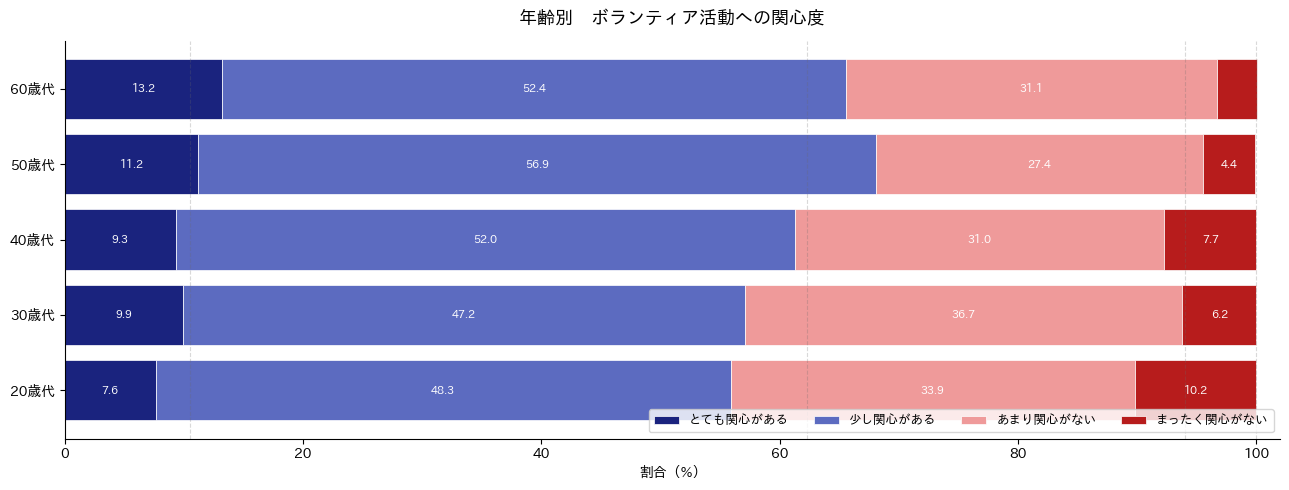

In [4]:
plot_stacked(df29, dcols(df29),
             '年齢別　ボランティア活動への関心度',
             colors=C_INTEREST, figsize=(13, 5))


### 2.2 性別（図表2-30）

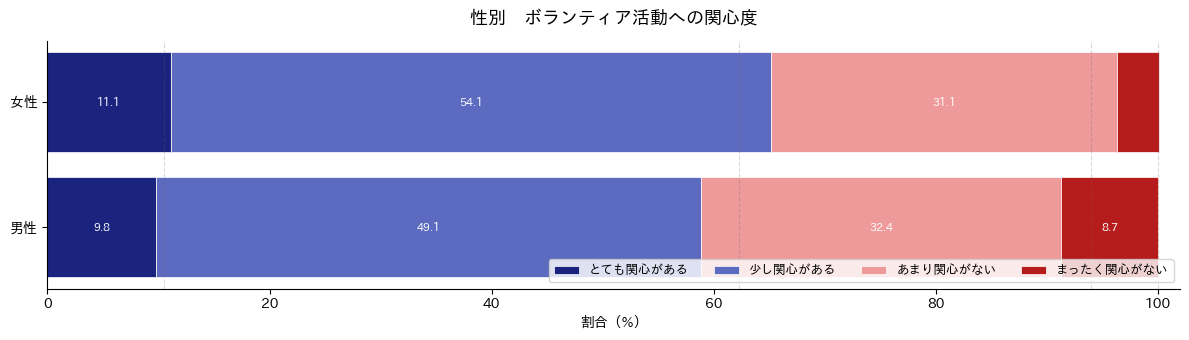

In [5]:
df30, _ = load_sheet('2-30')
plot_stacked(df30, dcols(df30),
             '性別　ボランティア活動への関心度',
             colors=C_INTEREST, figsize=(12, 3.5))


### 2.3 婚姻状況別（図表2-31）

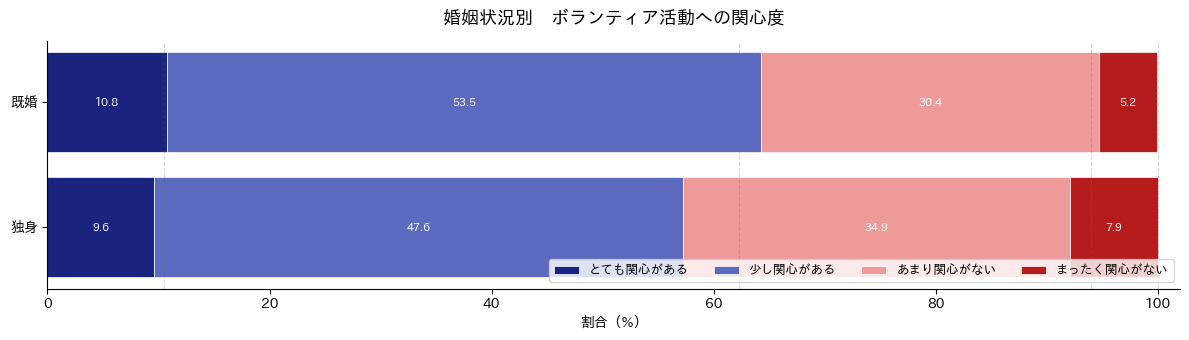

In [6]:
df31, _ = load_sheet('2-31')
plot_stacked(df31, dcols(df31),
             '婚姻状況別　ボランティア活動への関心度',
             colors=C_INTEREST, figsize=(12, 3.5))


### 2.4 地域別（図表2-32）

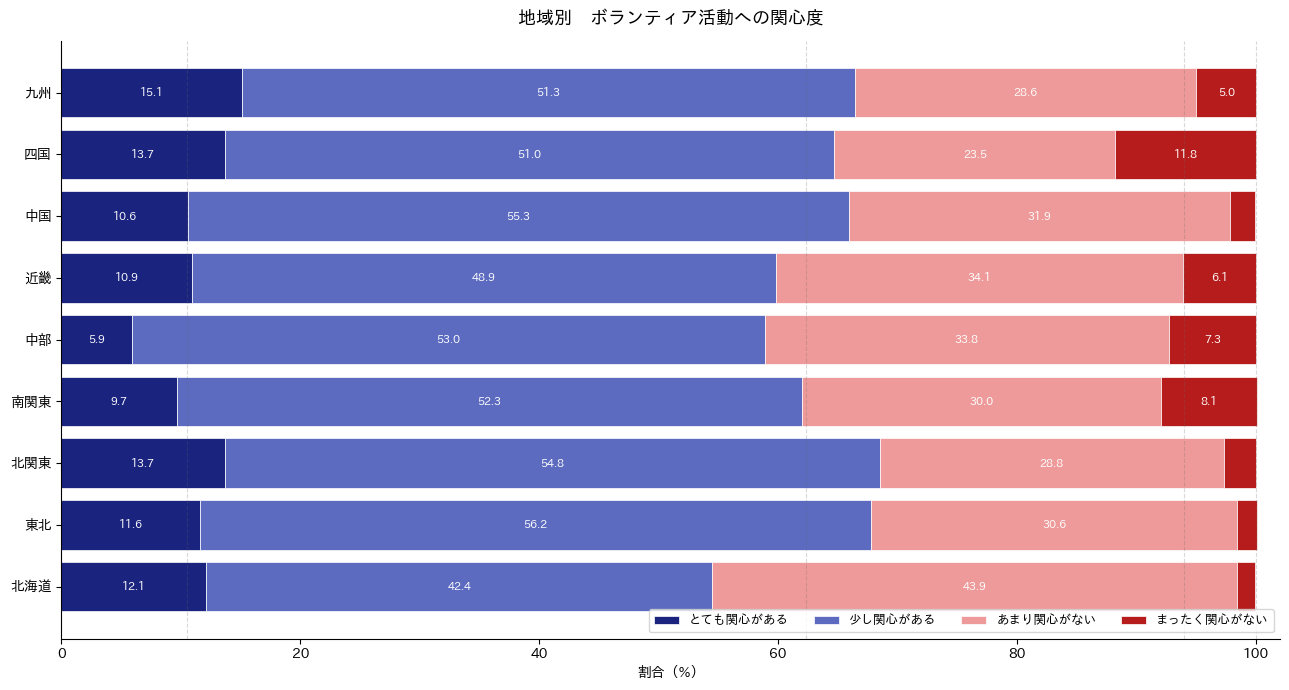

In [7]:
df32, _ = load_sheet('2-32')
plot_stacked(df32, dcols(df32),
             '地域別　ボランティア活動への関心度',
             colors=C_INTEREST, figsize=(13, 7))


### 2.5 職業別（図表2-33）

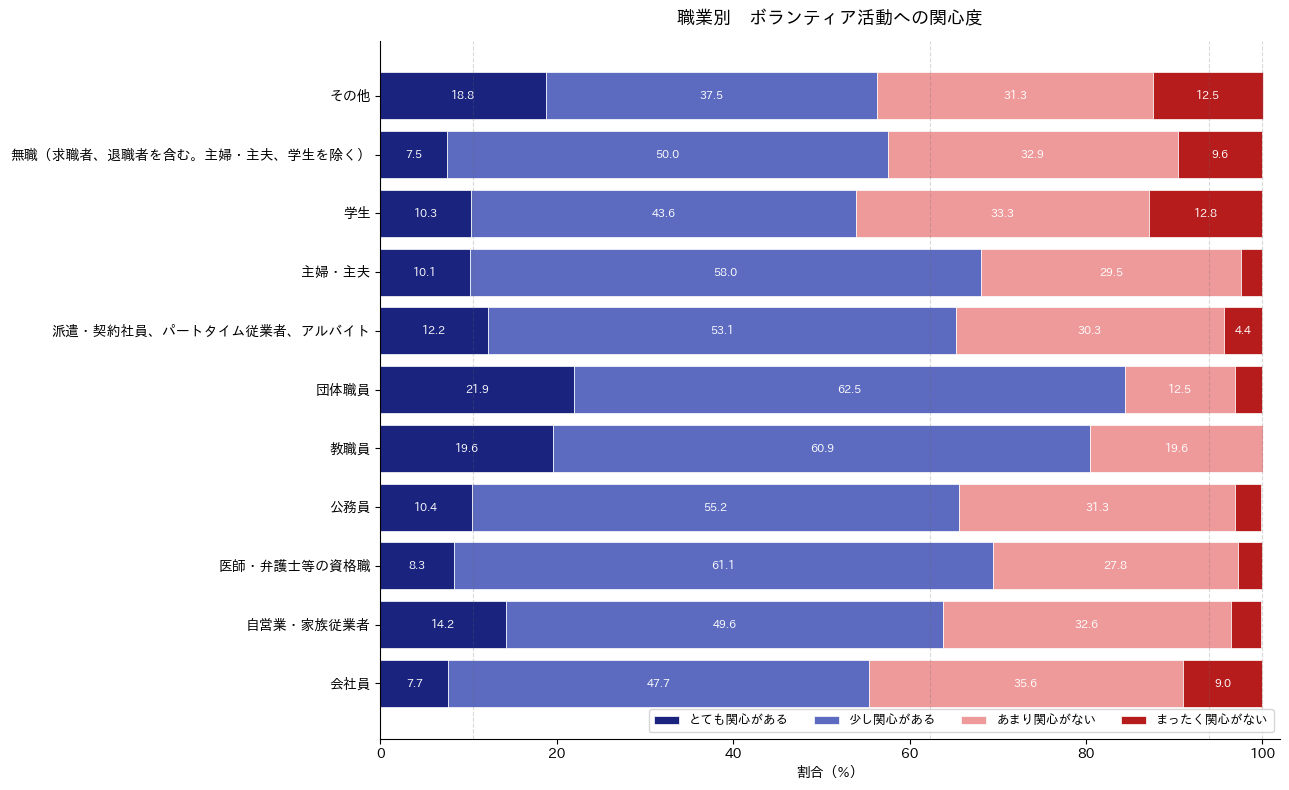

In [8]:
df33, _ = load_sheet('2-33')
plot_stacked(df33, dcols(df33),
             '職業別　ボランティア活動への関心度',
             colors=C_INTEREST, figsize=(13, 8))


### 2.6 年収別（図表2-34）

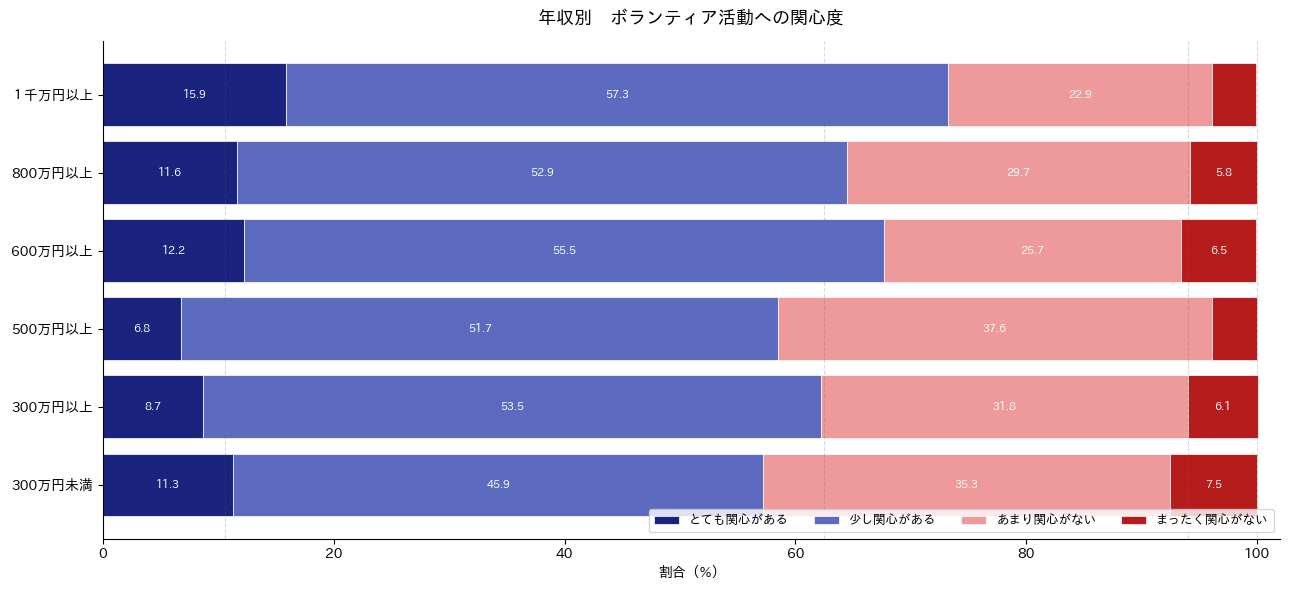

In [9]:
df34, _ = load_sheet('2-34')
plot_stacked(df34, dcols(df34),
             '年収別　ボランティア活動への関心度',
             colors=C_INTEREST, figsize=(13, 6))


### 2.7 考察

#### データから読み取れること

- **全体値**：「とても関心がある」10.5% ＋「少し関心がある」51.8% ＝ **約62%が関心あり**
  一方、後述する実際の経験率は約27%にとどまり、**関心と行動の間に約35ポイントのギャップ**が存在する
- **年齢別**：50代・60代で「とても関心がある」の割合が高い（11〜13%台）。
  20代は「まったく関心がない」が最も高く（10.2%）、若年層での関心の薄さが目立つ
- **性別**：女性（とても＋少し ≒ 65%）が男性（≒ 59%）を約6ポイント上回る
- **地域別**：東北・北関東は「とても関心がある」比率が比較的高い。
  東日本大震災（2011年）以降のボランティア機運の高まりが平成26年度時点でも残っている可能性がある
- **職業別**：主婦・無職・退職者で関心が高く、会社員・自営業では「あまり関心がない」が相対的に多い
- **年収別**：年収が高いほど「とても関心がある」の割合が高くなる傾向がある

#### 外部情報との照合 ※参考情報（Web検索による）

内閣府「社会意識に関する世論調査」（平成26〜27年度）では、
「社会のために役立ちたいと思う」と回答した割合は約70%に上るが、
実際の行動（ボランティア参加等）は30%未満にとどまる「関心-行動ギャップ」が指摘されている。
本データの結果と一致しており、情報提供・きっかけ作りの重要性が示唆される。


---
## 3. ボランティア活動経験の有無

「これまでにボランティア活動をしたことがあるか」を属性別に集計（択一回答）。
選択肢：**したことがある** / したことがない


### 3.1 年齢別（図表2-35）

         n  したことがある  したことがない
グループ                        
全体    1647     26.8     73.2
20歳代   237     27.4     72.6
30歳代   323     22.6     77.4
40歳代   323     26.9     73.1
50歳代   383     26.4     73.6
60歳代   381     30.4     69.6


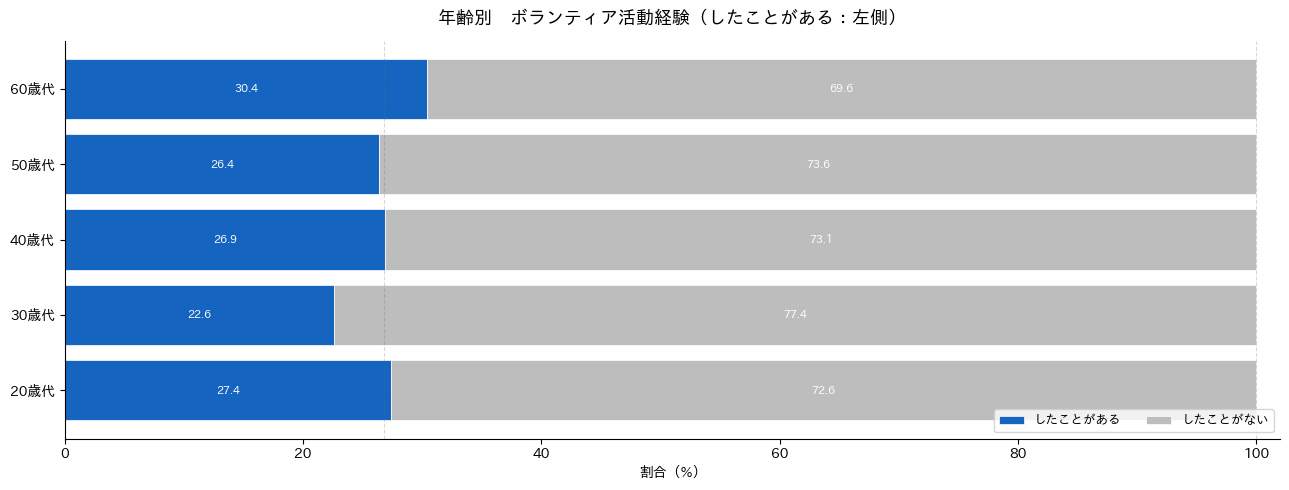

In [10]:
df35, _ = load_sheet('2-35')
print(df35.set_index('グループ').to_string())
plot_stacked(df35, dcols(df35),
             '年齢別　ボランティア活動経験（したことがある：左側）',
             colors=C_EXP, figsize=(13, 5))


### 3.2 性別（図表2-36）

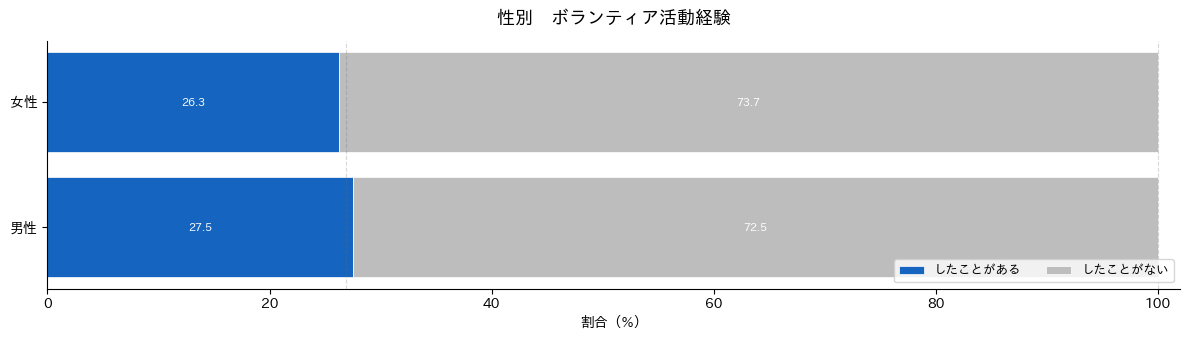

In [11]:
df36, _ = load_sheet('2-36')
plot_stacked(df36, dcols(df36),
             '性別　ボランティア活動経験',
             colors=C_EXP, figsize=(12, 3.5))


### 3.3 婚姻状況別（図表2-37）

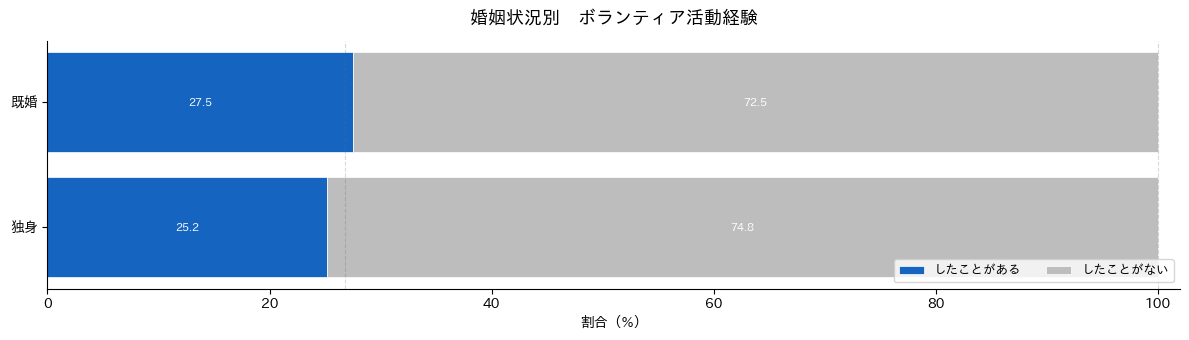

In [12]:
df37, _ = load_sheet('2-37')
plot_stacked(df37, dcols(df37),
             '婚姻状況別　ボランティア活動経験',
             colors=C_EXP, figsize=(12, 3.5))


### 3.4 地域別（図表2-38）

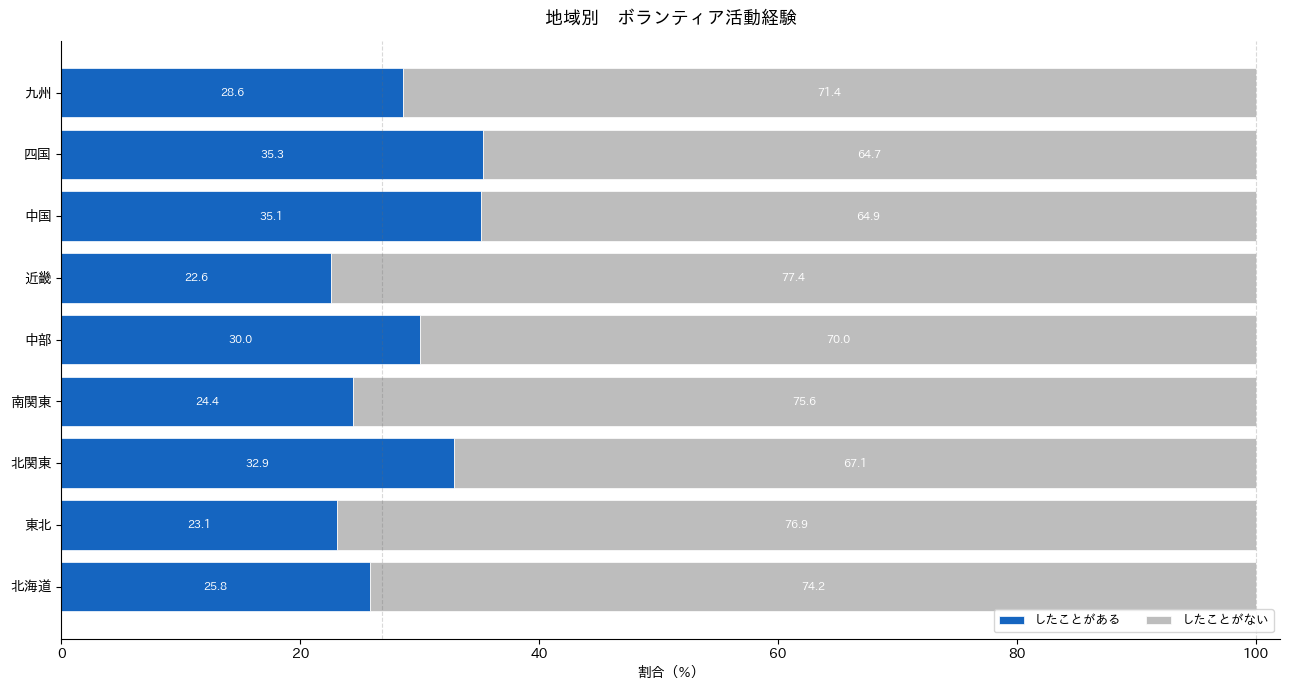

In [13]:
df38, _ = load_sheet('2-38')
plot_stacked(df38, dcols(df38),
             '地域別　ボランティア活動経験',
             colors=C_EXP, figsize=(13, 7))


### 3.5 職業別（図表2-39）

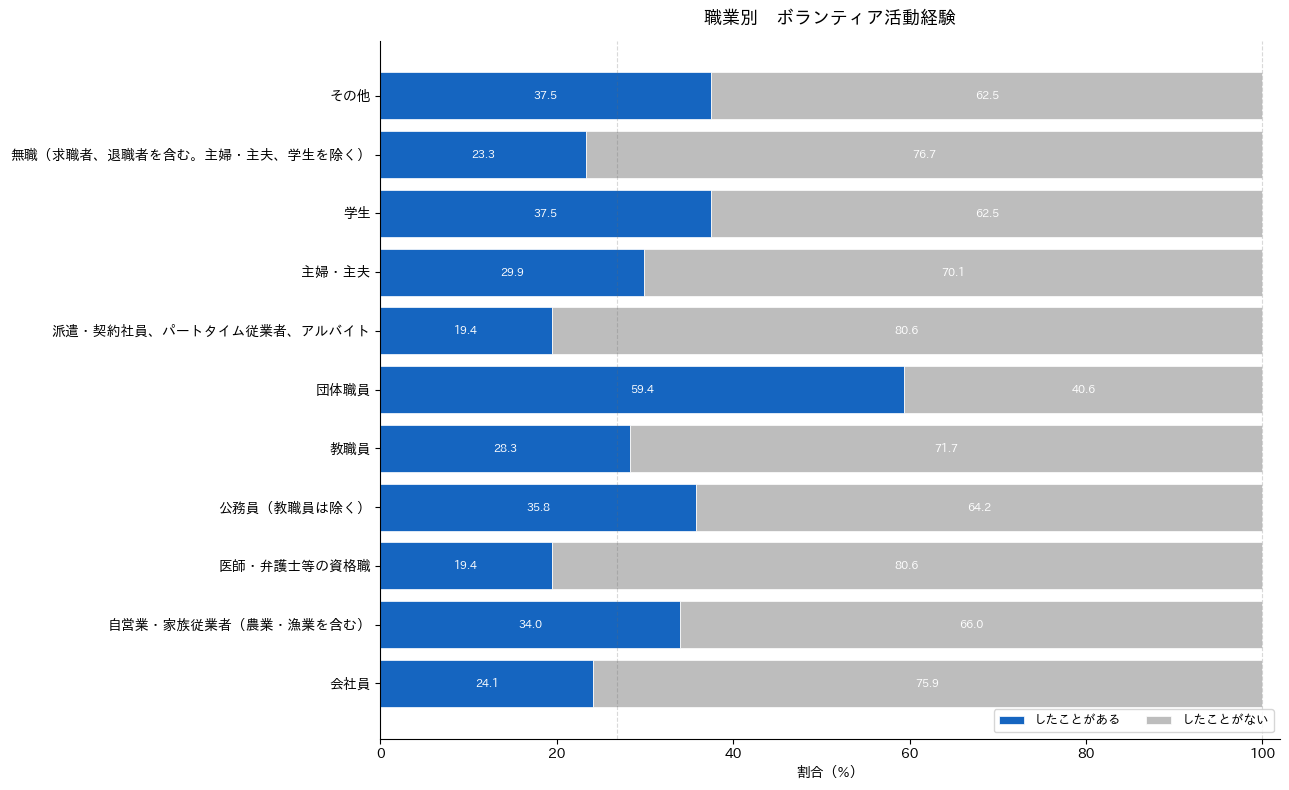

In [14]:
df39, _ = load_sheet('2-39')
plot_stacked(df39, dcols(df39),
             '職業別　ボランティア活動経験',
             colors=C_EXP, figsize=(13, 8))


### 3.6 年収別（図表2-40）

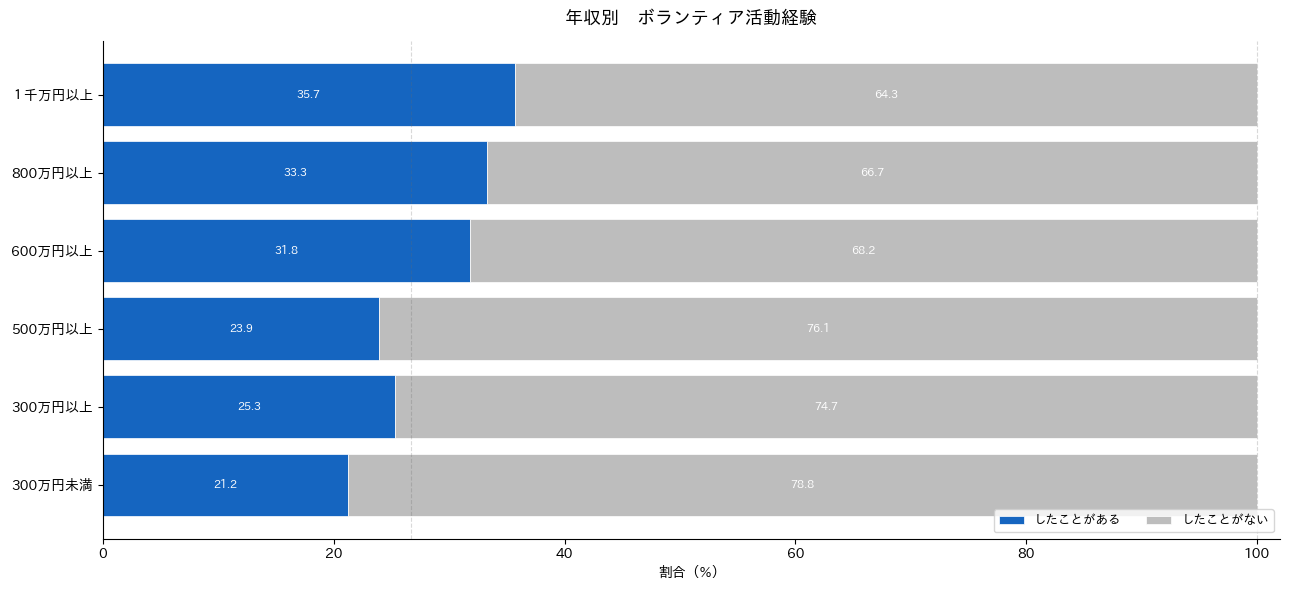

In [15]:
df40, _ = load_sheet('2-40')
plot_stacked(df40, dcols(df40),
             '年収別　ボランティア活動経験',
             colors=C_EXP, figsize=(13, 6))


### 3.7 ボランティア活動への関心別（図表2-41）

              n  したことがある  したことがない
グループ                             
全体         1645     26.9     73.1
とても関心がある    173     60.1     39.9
少し関心がある     852     31.1     68.9
あまり関心がない    522     12.8     87.2
まったく関心がない    98      6.1     93.9


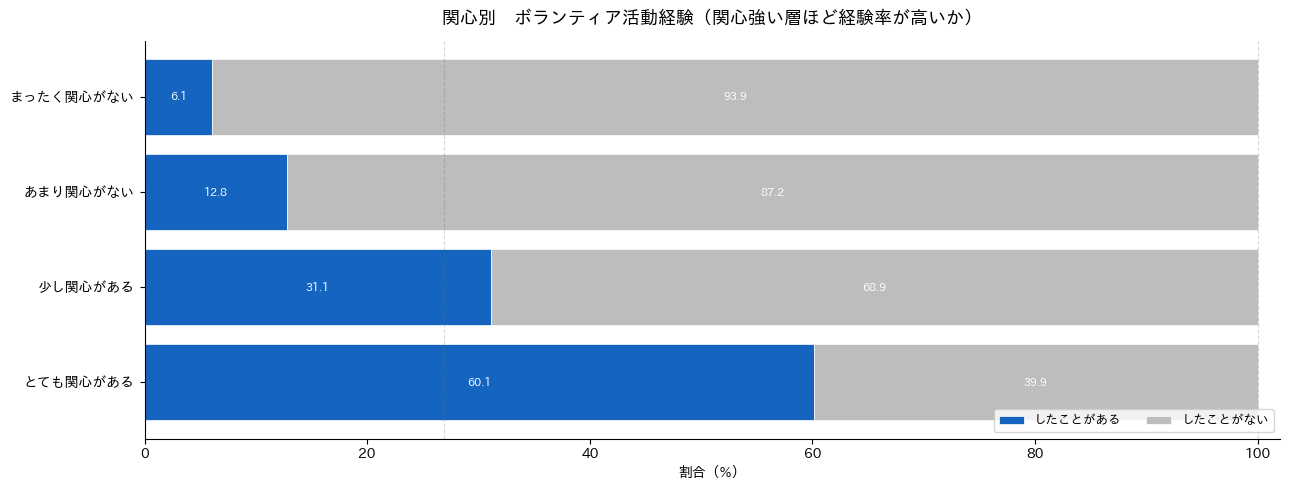

In [16]:
df41, _ = load_sheet('2-41')
print(df41.set_index('グループ').to_string())
plot_stacked(df41, dcols(df41),
             '関心別　ボランティア活動経験（関心強い層ほど経験率が高いか）',
             colors=C_EXP, figsize=(13, 5))


### 3.8 考察

#### データから読み取れること

- **全体の経験率は約27%**（約4人に1人）。関心率62%と比べて大幅に低く、関心→行動の転換が課題
- **年齢別**：60代が最も高く、20〜30代が低い。ただし大学生参加（クラブ活動等）を考慮すると
  若年層の実態はやや異なる可能性がある
- **性別**：男女差は小さい（約1ポイント程度）
- **地域別**：北関東（32.9%）が最も高く、近畿（約23%前後）が低い傾向。
  東日本大震災の影響による東北・北関東での参加率上昇が示唆される
- **職業別**：主婦・退職者・無職層で高く、会社員で低い（仕事による時間制約）
- **年収別**：800万円以上の高収入層で経験率が最も高い（時間・経済的余裕との正相関）
- **関心別**：「とても関心がある」層でも経験率は約60%弱にとどまり、
  「強い関心があるが行動に移せていない」層が相当数いる

#### 外部情報との照合 ※参考情報（Web検索による）

総務省「社会生活基本調査」（平成28年版）によると、
過去1年間にボランティア活動を行った人の割合は約26%（本調査と同水準）。
60代が他世代を上回る傾向は同調査でも一貫して確認されている。


---
## 4. ボランティア活動に参加した分野

ボランティア経験者（n≈435）を対象に、どの分野に参加したかを複数回答で調査。
※「平成25年度は参加していない」を含む13選択肢


### 4.1 全体ランキング（図表2-42 全体行）

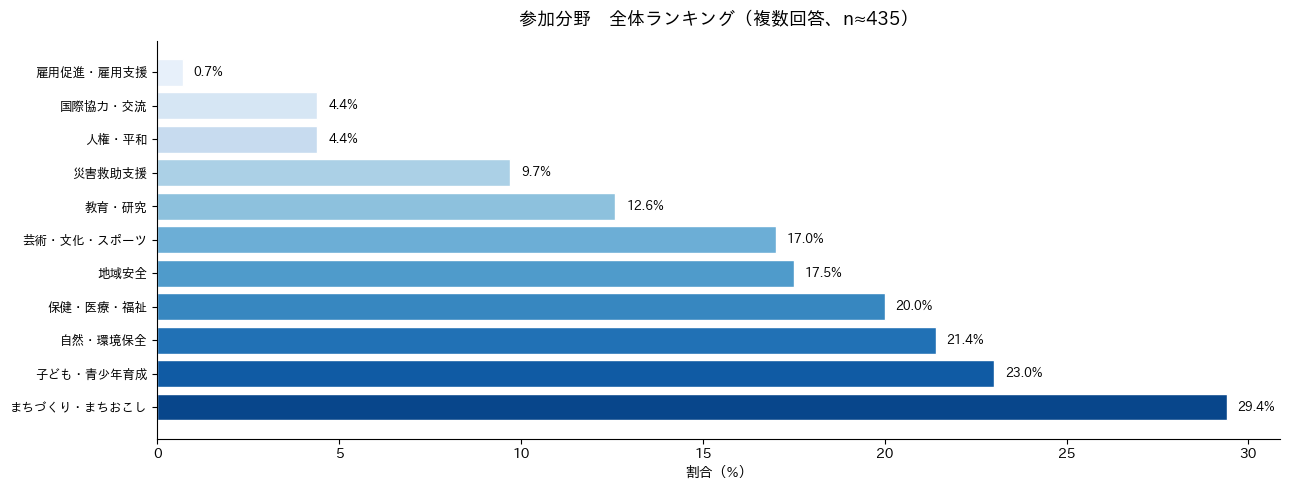

In [17]:
df42, _ = load_sheet('2-42')
cols42 = dcols(df42)
# 「平成25年度は参加していない」は分野外なので除外して表示
field_cols = [c for c in cols42 if '参加していない' not in c and 'その他' not in c]
plot_total_rank(df42, field_cols,
                '参加分野　全体ランキング（複数回答、n≈435）',
                color='#1565C0')


### 4.2 性別比較（図表2-42）

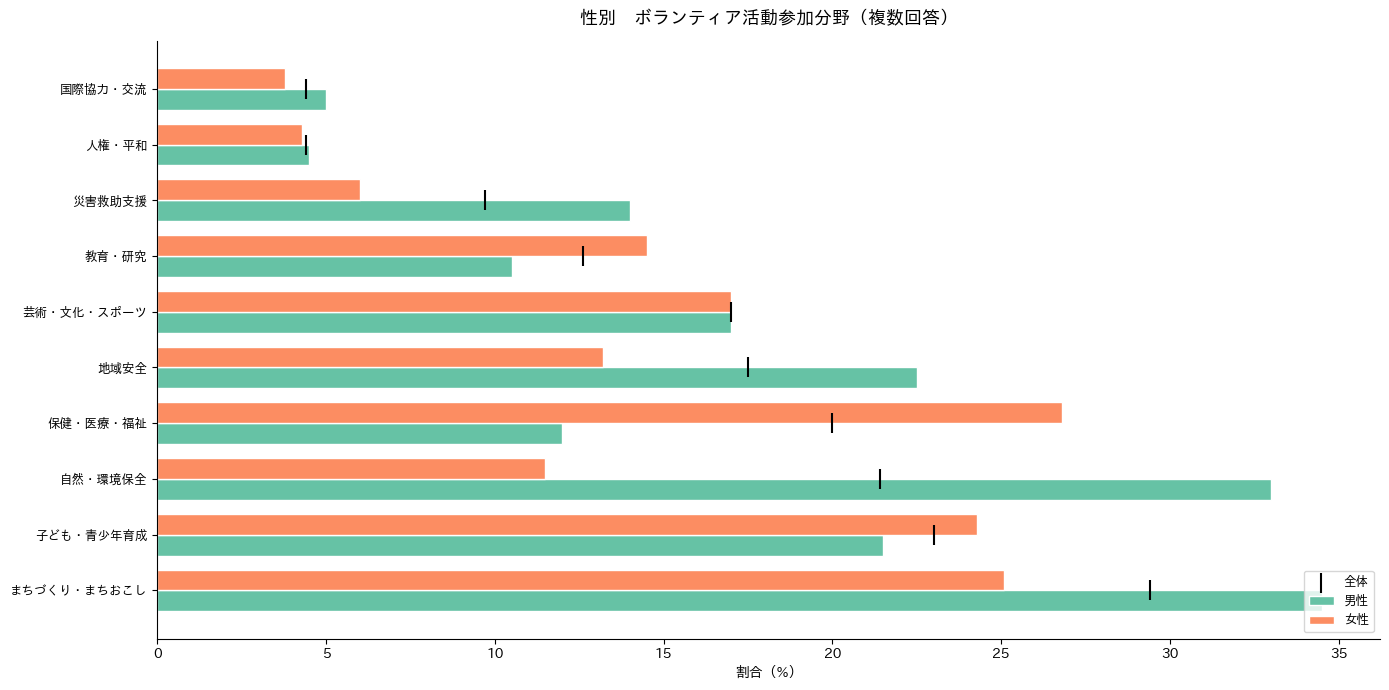

In [18]:
plot_multi_grouped(df42, field_cols,
                   '性別　ボランティア活動参加分野（複数回答）',
                   top_n=10, figsize=(14, 7))


### 4.3 年齢別（図表2-43）

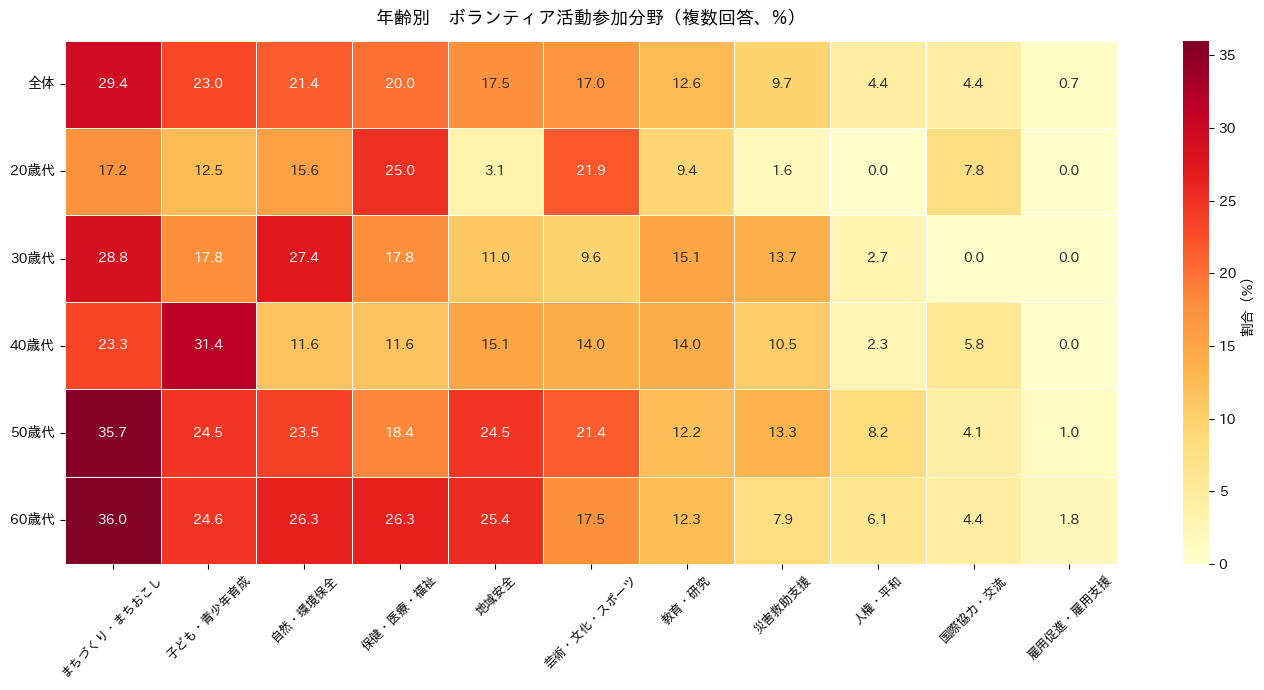

In [19]:
df43, _ = load_sheet('2-43')
cols43 = dcols(df43)
field_cols43 = [c for c in cols43 if '参加していない' not in c and 'その他' not in c]
plot_heatmap(df43, field_cols43,
             '年齢別　ボランティア活動参加分野（複数回答、%）',
             top_n=12, figsize=(14, 7))


### 4.4 地域別（図表2-45）

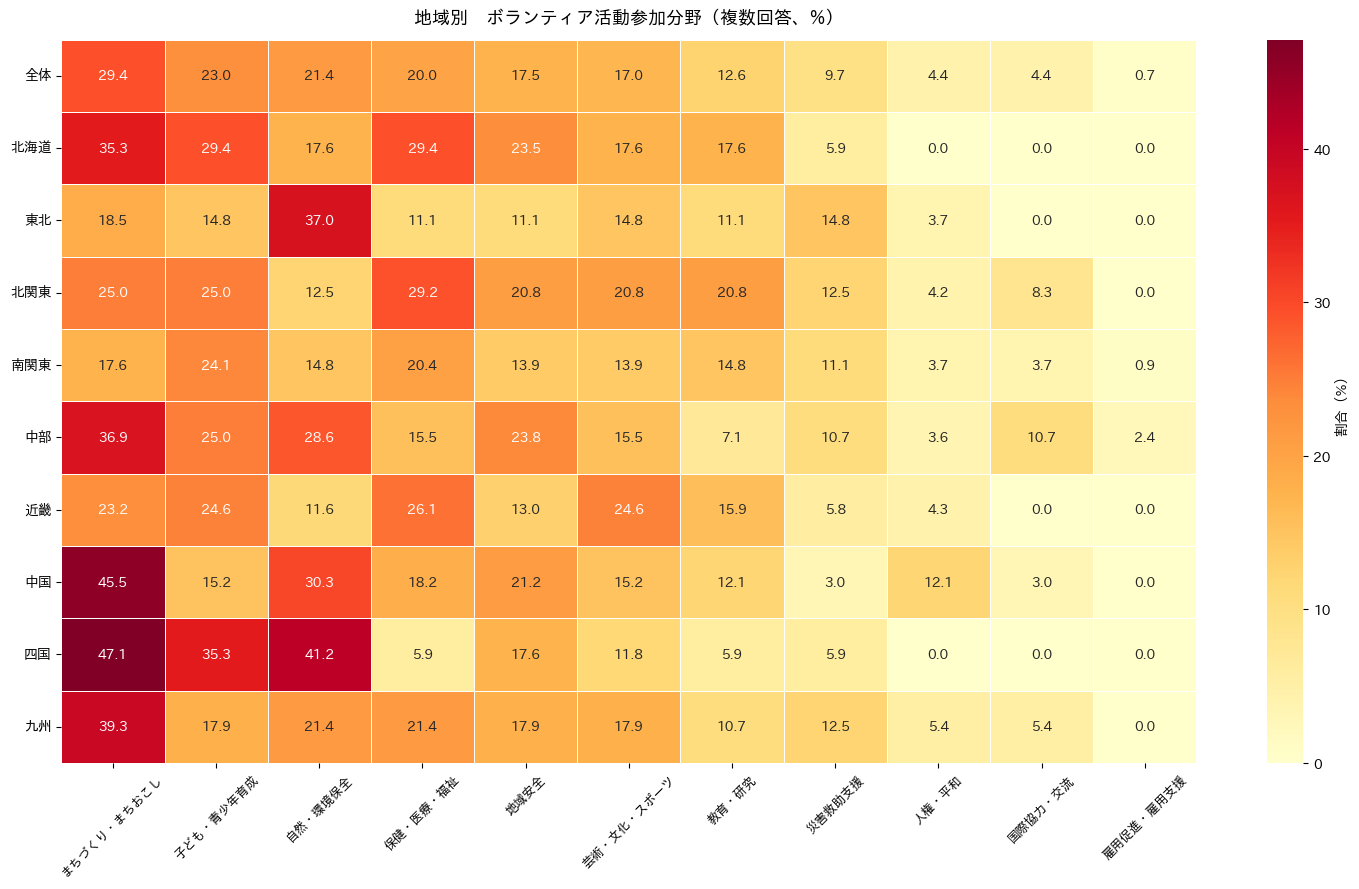

In [20]:
df45, _ = load_sheet('2-45')
cols45 = dcols(df45)
field_cols45 = [c for c in cols45 if '参加していない' not in c and 'その他' not in c]
plot_heatmap(df45, field_cols45,
             '地域別　ボランティア活動参加分野（複数回答、%）',
             top_n=12, figsize=(15, 9))


### 4.5 職業別（図表2-46）

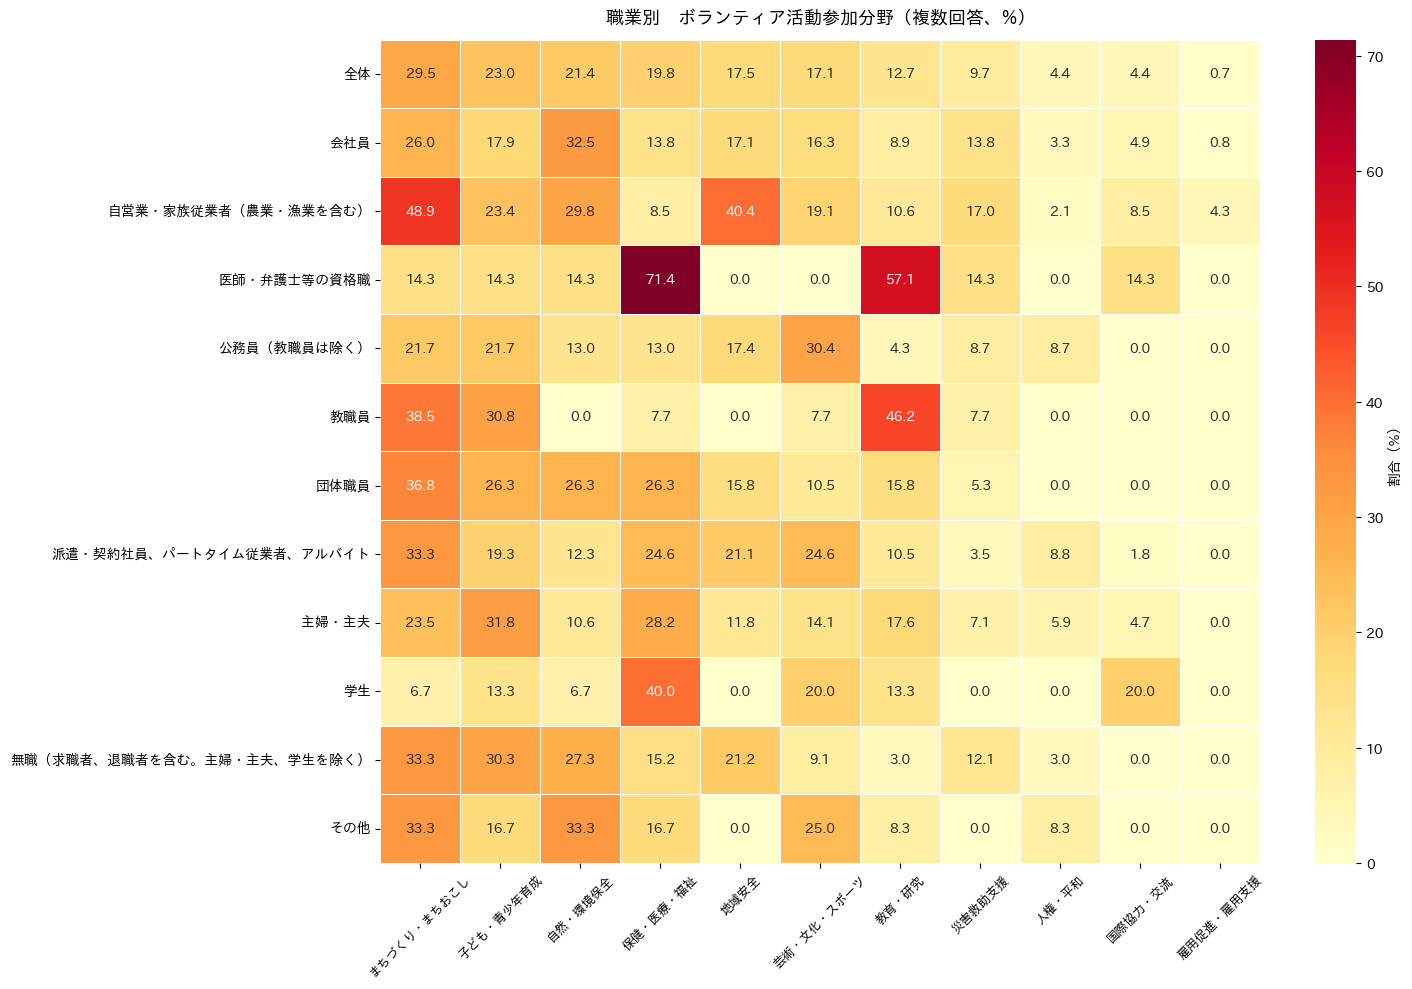

In [21]:
df46, _ = load_sheet('2-46')
cols46 = dcols(df46)
field_cols46 = [c for c in cols46 if '参加していない' not in c and 'その他' not in c]
plot_heatmap(df46, field_cols46,
             '職業別　ボランティア活動参加分野（複数回答、%）',
             top_n=12, figsize=(15, 10))


### 4.6 考察

#### データから読み取れること

- **参加分野 Top3（全体）**：
  ①まちづくり・まちおこし（約29%）　②子ども・青少年育成（約23%）　③自然・環境保全（約21%）
  地域密着型・身近なテーマへの参加が最も多い
- **性別差が顕著な分野**：
  男性は「自然・環境保全」（33% vs 女性12%）・「地域安全」が高く、アウトドア・防犯系に集中
  女性は「保健・医療・福祉」（27% vs 男性12%）・「子ども・青少年育成」が高く、ケア系分野に集中
- **年齢別**：20〜30代は「子ども・青少年育成」「まちづくり」が多く、
  60代は「保健・医療・福祉」「高齢者支援」への参加が増える傾向
- **「平成25年度は参加していない」が約10%**存在：過去経験はあるが最近1年は未参加という継続率の課題がある

#### 外部情報との照合 ※参考情報（Web検索による）

内閣府「特定非営利活動法人及び市民の社会貢献に関する実態調査（平成26年度）」の公表概要では、
「まちづくり・まちおこし」「子ども・青少年育成」が参加分野の上位であることが報告されており、本データと一致する。
なお、高齢化の進展に伴い「保健・医療・福祉」分野のニーズは今後も増加が見込まれる（厚生労働省推計）。


---
## 5. ボランティア活動への参加理由

経験者を対象に参加した理由を複数回答で調査（8選択肢）。


### 5.1 全体ランキング（図表2-48 全体行）

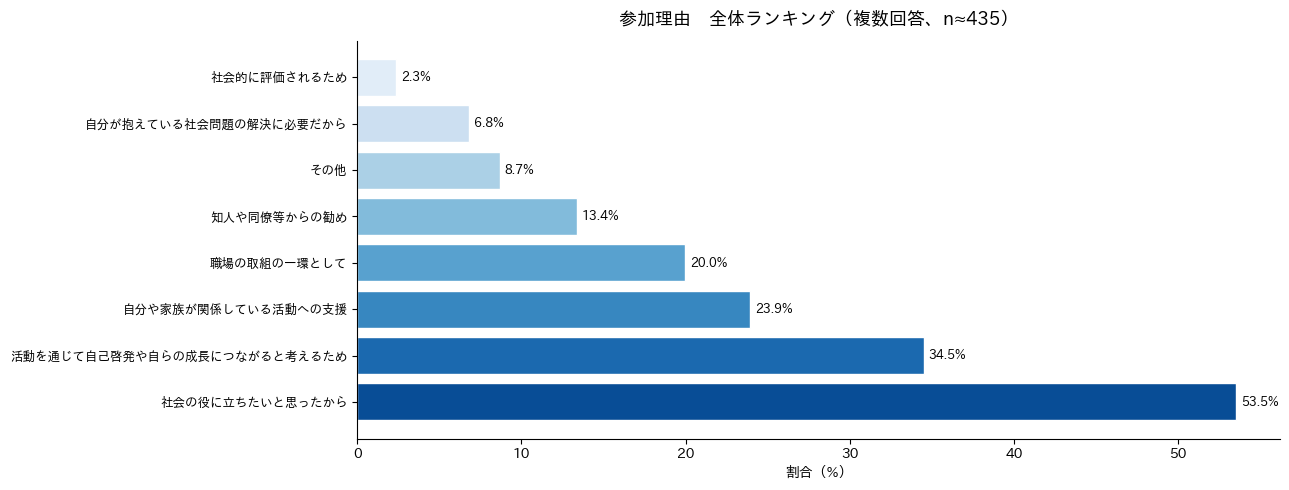

In [22]:
df48, _ = load_sheet('2-48')
cols48 = dcols(df48)
plot_total_rank(df48, cols48,
                '参加理由　全体ランキング（複数回答、n≈435）')


### 5.2 性別比較（図表2-48）

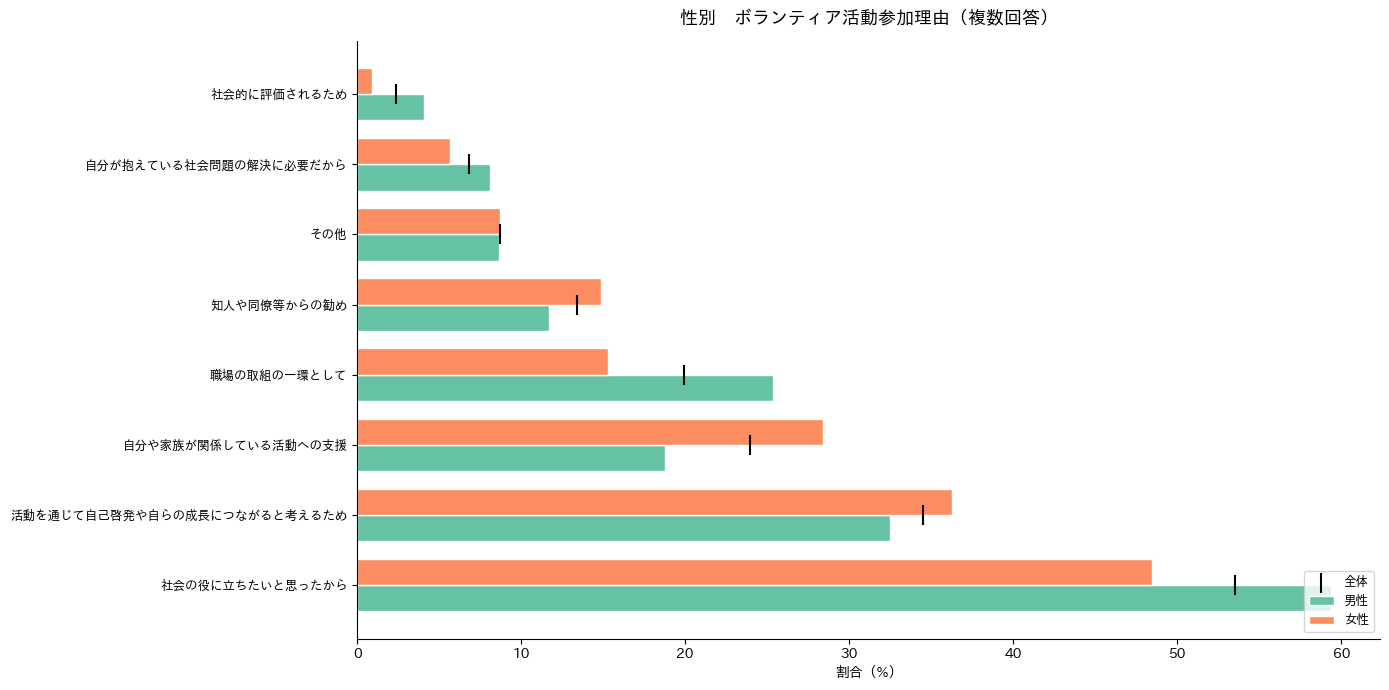

In [23]:
plot_multi_grouped(df48, cols48,
                   '性別　ボランティア活動参加理由（複数回答）',
                   top_n=8, figsize=(14, 7))


### 5.3 年齢別（図表2-49）

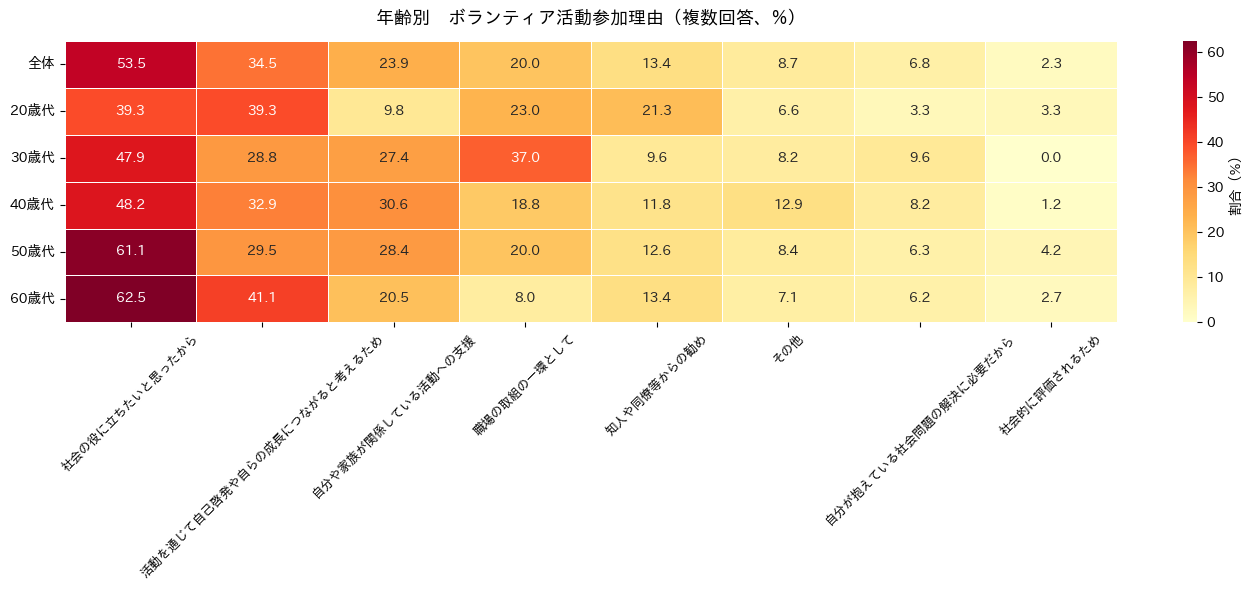

In [24]:
df49, _ = load_sheet('2-49')
cols49 = dcols(df49)
plot_heatmap(df49, cols49,
             '年齢別　ボランティア活動参加理由（複数回答、%）',
             top_n=8, figsize=(14, 6))


### 5.4 関心別（図表2-54）

             n  活動を通じて自己啓発や自らの成長につながると考えるため  社会の役に立ちたいと思ったから  職場の取組の一環として  知人や同僚等からの勧め  自分や家族が関係している活動への支援  社会的に評価されるため  自分が抱えている社会問題の解決に必要だから  その他
グループ                                                                                                                                               
全体         426                         34.5             53.5         20.0         13.4                23.9          2.3                    6.8  8.7
とても関心がある   101                         51.5             74.3         11.9          7.9                22.8          4.0                   14.9  8.9
少し関心がある    257                         33.5             54.1         20.6         12.5                26.1          1.6                    3.9  7.0
あまり関心がない    62                         14.5             21.0         29.0         25.8                19.4          3.2                    6.5 12.9
まったく関心がない    6                          0.0             16.7         33.3         16.7                 0.0      

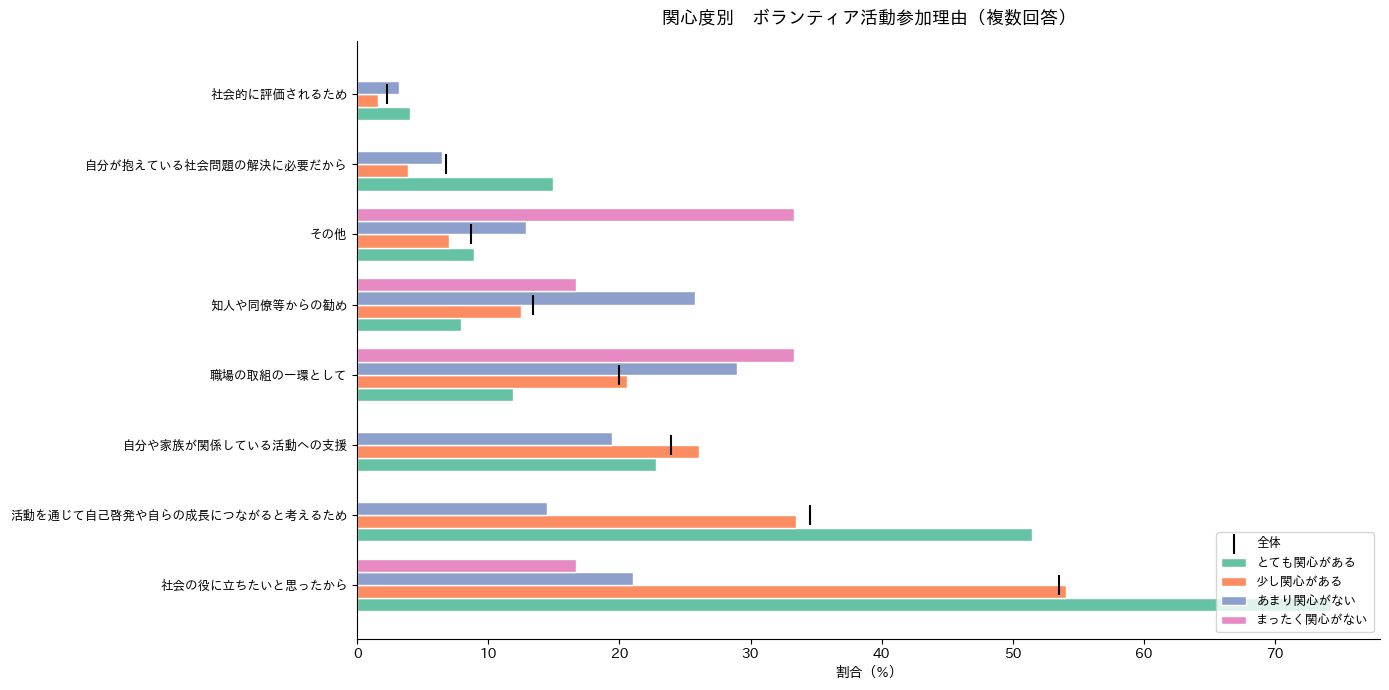

In [25]:
df54, _ = load_sheet('2-54')
cols54 = dcols(df54)
print(df54.set_index('グループ').to_string())
plot_multi_grouped(df54, cols54,
                   '関心度別　ボランティア活動参加理由（複数回答）',
                   top_n=8, figsize=(14, 7))


### 5.5 NPO法人への関心別（図表2-55）

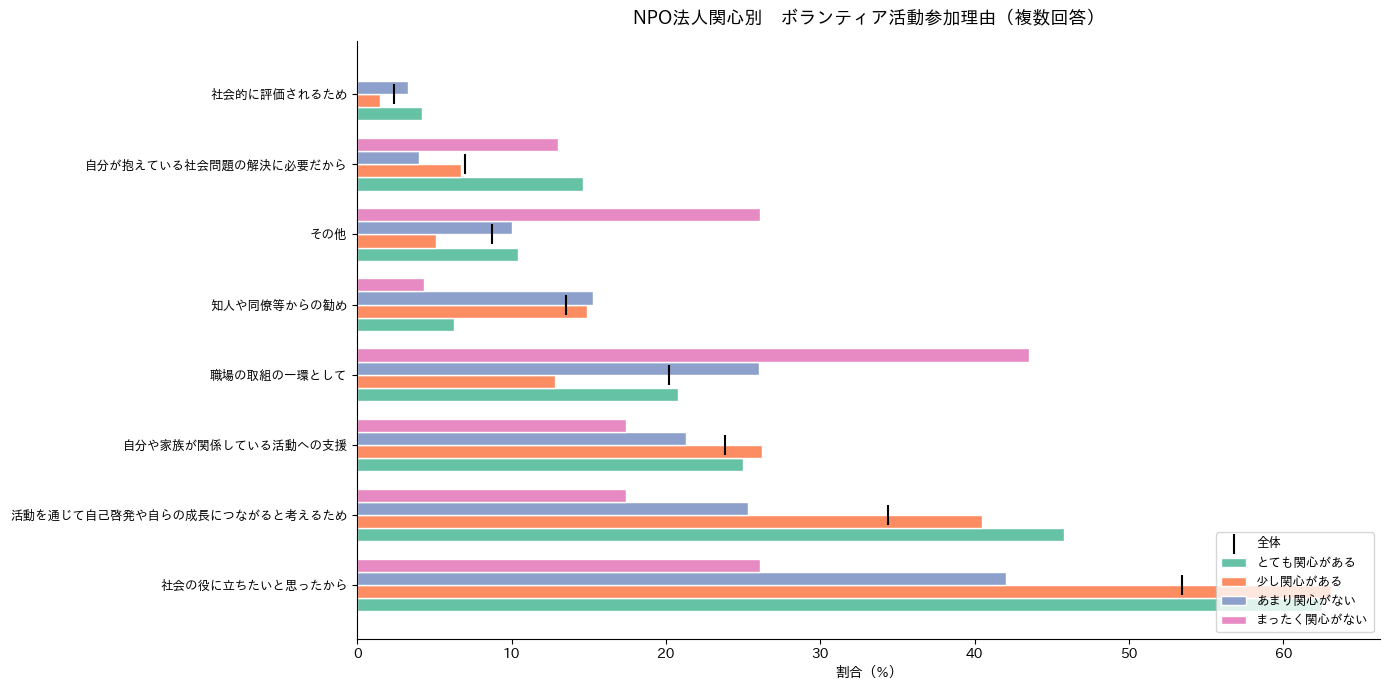

In [26]:
df55, _ = load_sheet('2-55')
cols55 = dcols(df55)
plot_multi_grouped(df55, cols55,
                   'NPO法人関心別　ボランティア活動参加理由（複数回答）',
                   top_n=8, figsize=(14, 7))


### 5.6 考察

#### データから読み取れること

- **参加理由 Top（全体）**：
  ①社会の役に立ちたいと思ったから　②自己啓発・自らの成長につながる　③地域・社会への貢献感
  **内発的動機（利他主義・自己成長）** が中心
- **性別差**：
  女性は「社会の役に立ちたい」「誰かの役に立てる活動だから」など利他的動機が強め
  男性は「職場の取組の一環として」「スキルを活かしたい」など外発的・機能的動機も一定程度ある
- **年齢別**：
  若年層（20代）では「楽しそう・興味があった」「友人・知人の誘い」が多く、きっかけ依存
  高齢層（60代）では「地域・社会への貢献」「余暇の有効活用」が主動機
- **関心別**：「とても関心がある」層は「社会の役に立ちたい」が突出して高く、内発的動機が強い
  「少し関心がある」層では「職場の取組」「誘われた」など外発的要因の比率が上がる

#### 政策的示唆

外発的きっかけ（職場のボランティア休暇制度、学校教育プログラム、友人の誘い）が
行動開始の契機として有効であることがデータから示唆される。
「関心はあるがきっかけがない」層へは、マッチングサービスや職場制度の整備が効果的と考えられる。


---
## 6. ボランティア活動参加の妨げとなる要因

全回答者（ボランティア未参加者含む）を対象に、参加しない・できない理由を複数回答で調査（11選択肢）。


### 6.1 全体ランキング（図表2-57 全体行）

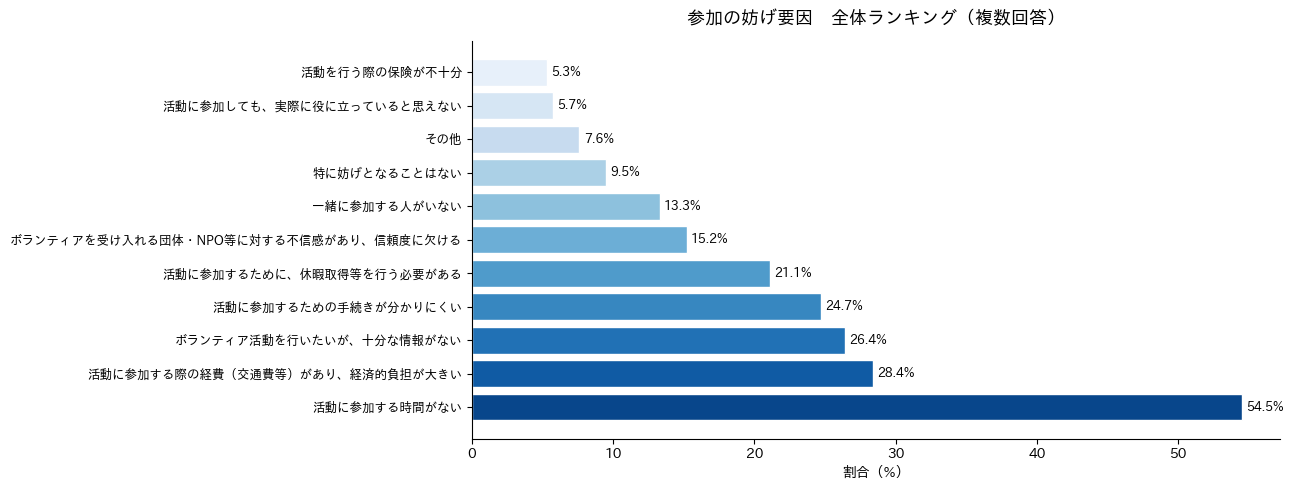

In [27]:
df57, _ = load_sheet('2-57')
cols57 = dcols(df57)
plot_total_rank(df57, cols57,
                '参加の妨げ要因　全体ランキング（複数回答）')


### 6.2 年齢別（図表2-56）

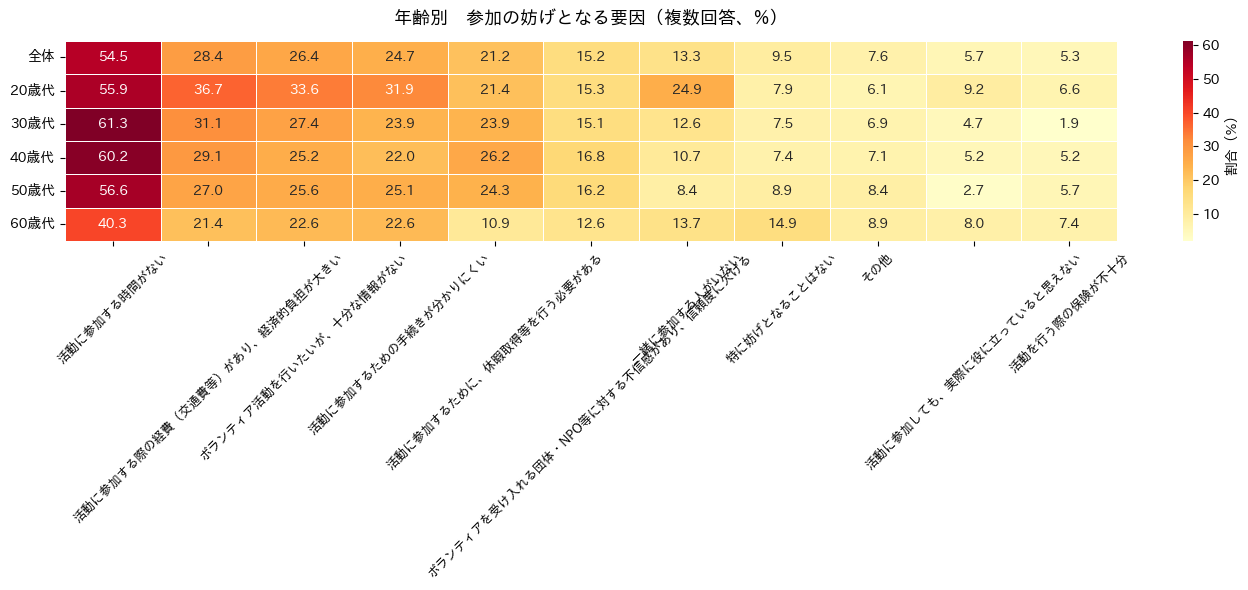

In [28]:
df56, _ = load_sheet('2-56')
cols56 = dcols(df56)
plot_heatmap(df56, cols56,
             '年齢別　参加の妨げとなる要因（複数回答、%）',
             top_n=11, figsize=(14, 6))


### 6.3 性別比較（図表2-57）

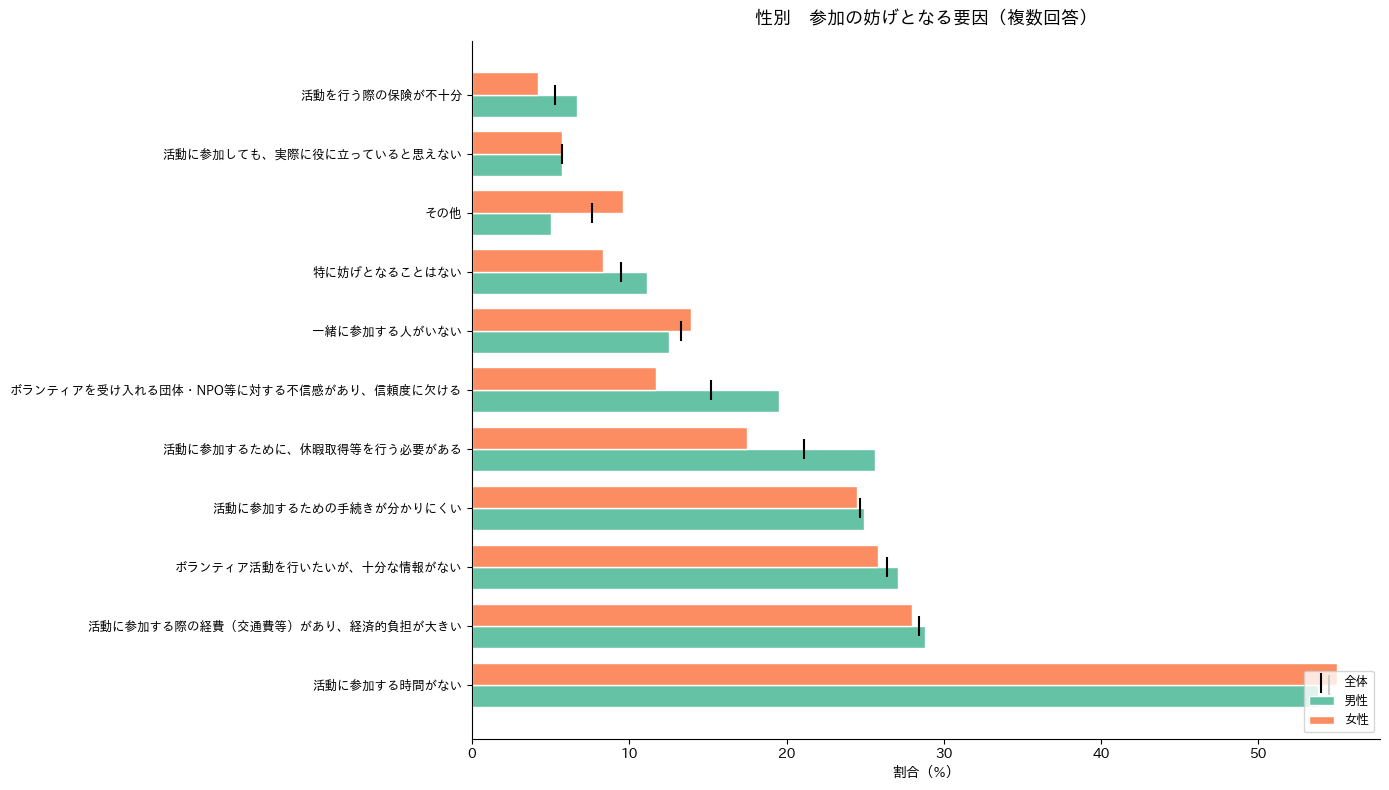

In [29]:
plot_multi_grouped(df57, cols57,
                   '性別　参加の妨げとなる要因（複数回答）',
                   top_n=11, figsize=(14, 8))


### 6.4 関心別（図表2-62）

              n  ボランティア活動を行いたいが、十分な情報がない  活動に参加する際の経費（交通費等）があり、経済的負担が大きい  活動に参加しても、実際に役に立っていると思えない  ボランティアを受け入れる団体・NPO等に対する不信感があり、信頼度に欠ける  活動に参加するための手続きが分かりにくい  活動に参加する時間がない  活動に参加するために、休暇取得等を行う必要がある  一緒に参加する人がいない  活動を行う際の保険が不十分  特に妨げとなることはない  その他
グループ                                                                                                                                                                                                                                                   
全体         1576                     26.4                            28.4                       5.7                                   15.2                  24.7          54.5                      21.2          13.3            5.3           9.5  7.6
とても関心がある    162                     38.3                            27.2                       3.7                                   11.7                  25.9          43.8                      17.3           8.6            4.9          13.0 11.1
少し関心がある 

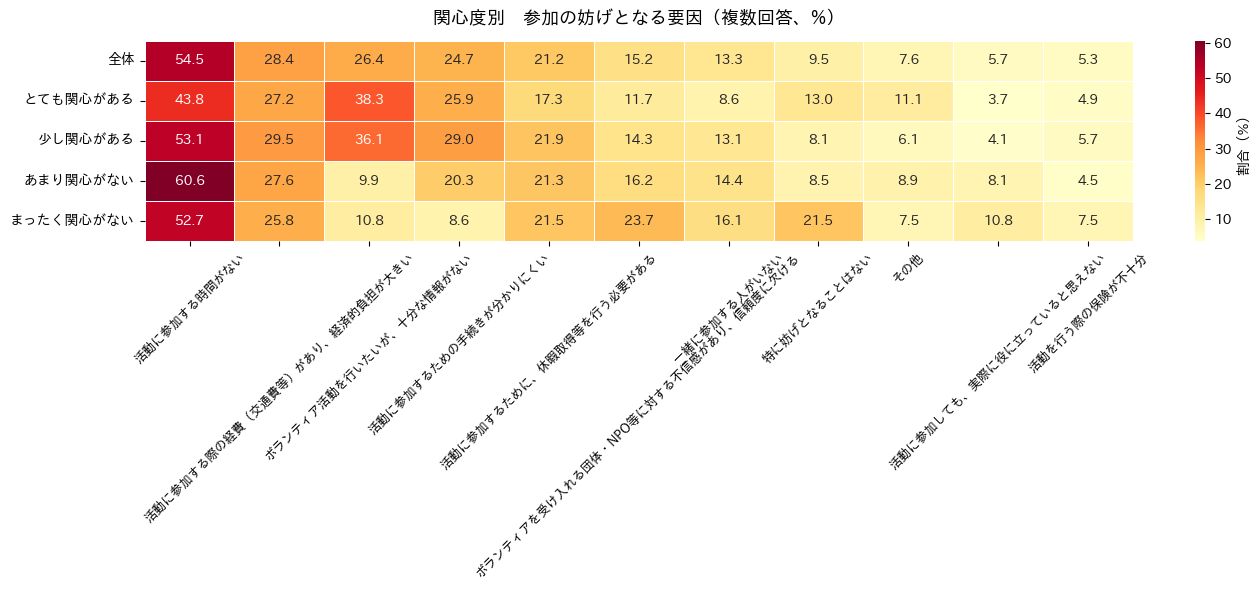

In [30]:
df62, _ = load_sheet('2-62')
cols62 = dcols(df62)
print(df62.set_index('グループ').to_string())
plot_heatmap(df62, cols62,
             '関心度別　参加の妨げとなる要因（複数回答、%）',
             top_n=11, figsize=(14, 6))


### 6.5 地域別（図表2-59）

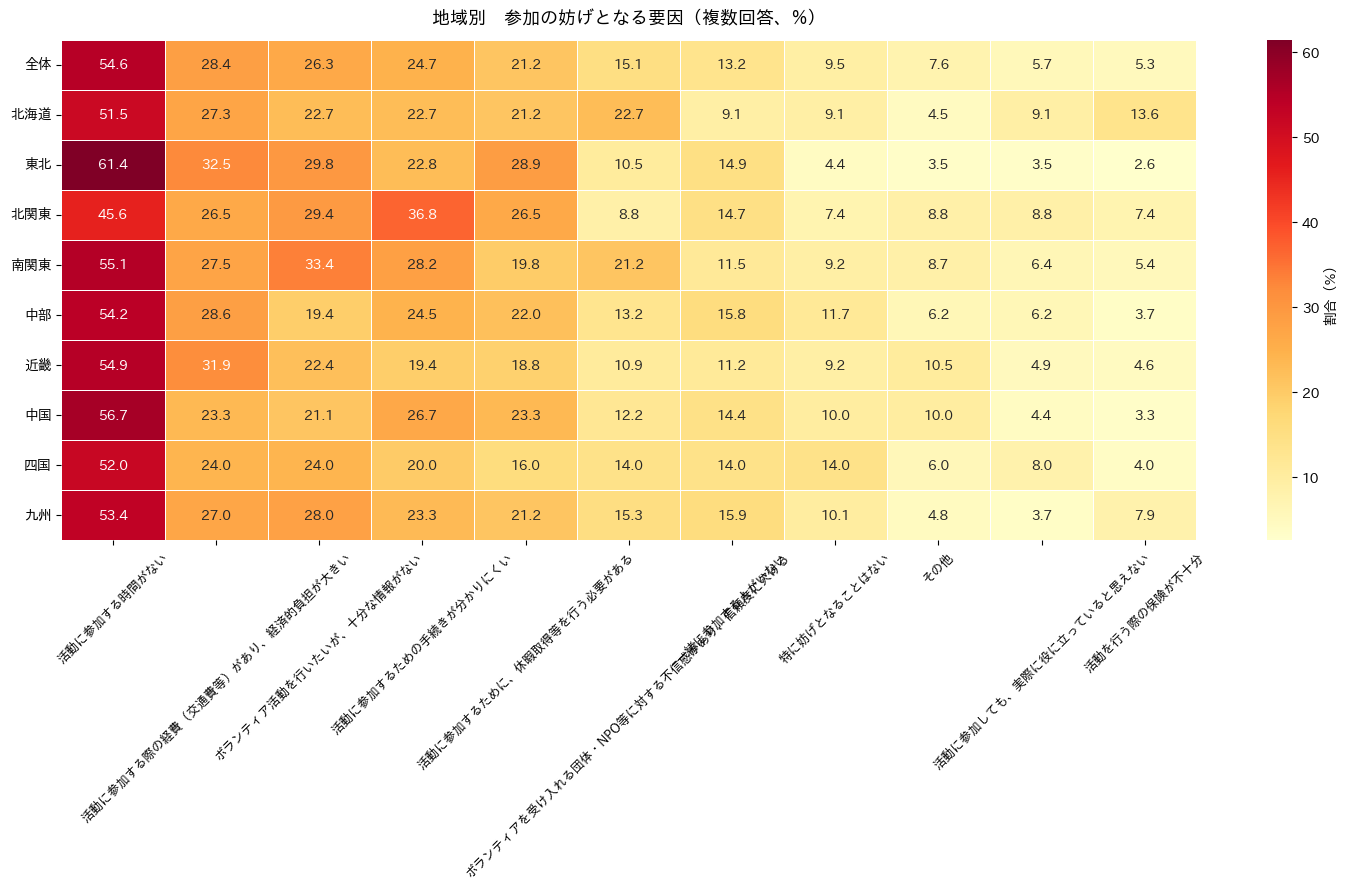

In [31]:
df59, _ = load_sheet('2-59')
cols59 = dcols(df59)
plot_heatmap(df59, cols59,
             '地域別　参加の妨げとなる要因（複数回答、%）',
             top_n=11, figsize=(15, 9))


### 6.6 考察

#### データから読み取れること

- **妨げ要因 Top（全体）**：
  ①仕事・学業が忙しく時間がない（最多）　②きっかけ・機会がない　③十分な情報がない
  **「時間なし」「きっかけなし」「情報なし」** の三要因が構造的障壁
- **年齢別**：
  20〜40代（現役世代）：「仕事・学業」が圧倒的1位。時間制約が最大のボトルネック
  60代以上（シニア層）：「体力・健康上の問題」「情報不足」が上位に浮上
- **性別**：
  女性では「家事・育児・介護で時間がない」が男性より大幅に高く、
  ダブルケア（仕事＋家庭）問題がボランティア参加の壁となっている
- **関心別で重要な示唆**：
  「とても関心がある」層でも妨げ1位は「時間がない」で、
  2位に「きっかけ・機会がない」が続く。
  関心があっても参加できない「**潜在的ボランティア層**」が多数存在することが明確

#### 外部情報との照合 ※参考情報（Web検索による）

内閣府「特定非営利活動法人及び市民の社会貢献に関する実態調査」では、
参加しない理由の1位は一貫して「時間がない」であることが複数年度にわたり報告されている。
女性の「家事・育児」負担については、男女共同参画白書（内閣府、令和5年版）でも
社会参加を阻む構造的要因として継続的に指摘されている。


---
## 7. 国・地方自治体等への要望

ボランティア活動促進のため国・自治体等に何をしてほしいかを複数回答で調査（8選択肢）。


### 7.1 全体ランキング（図表2-65 全体行）

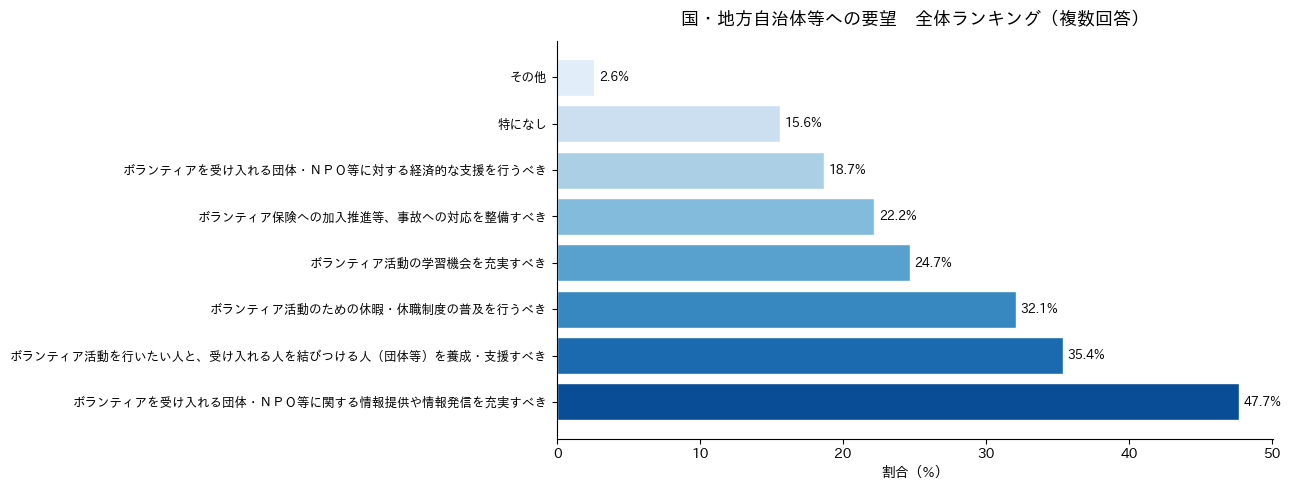

In [32]:
df65, _ = load_sheet('2-65')
cols65 = dcols(df65)
plot_total_rank(df65, cols65,
                '国・地方自治体等への要望　全体ランキング（複数回答）')


### 7.2 年齢別（図表2-64）

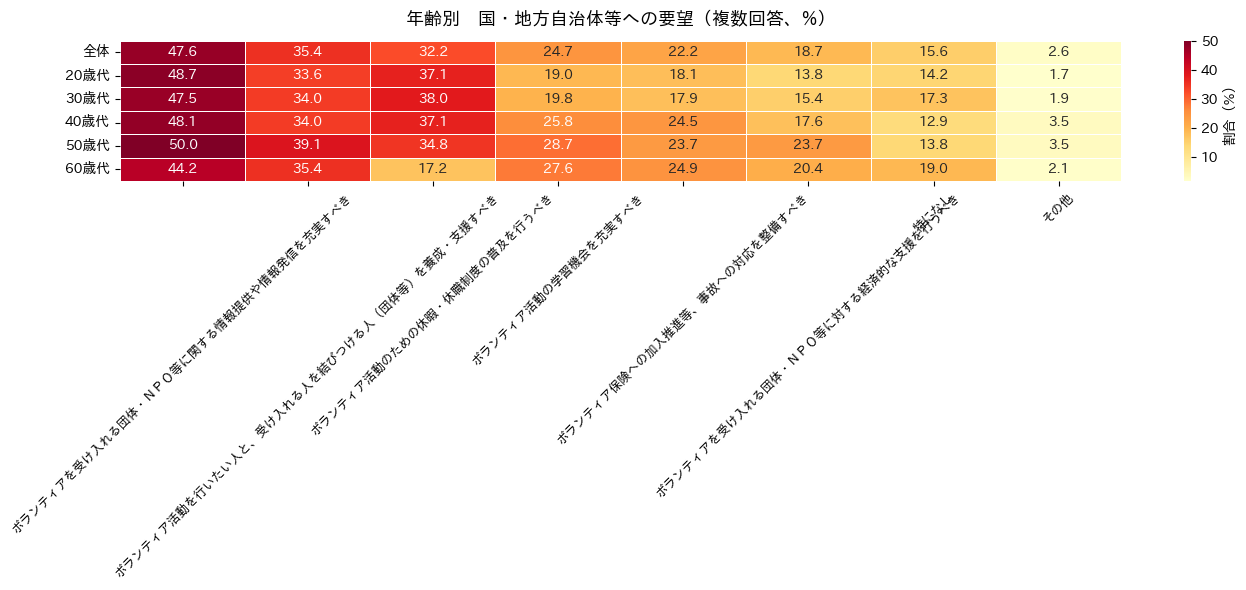

In [33]:
df64, _ = load_sheet('2-64')
cols64 = dcols(df64)
plot_heatmap(df64, cols64,
             '年齢別　国・地方自治体等への要望（複数回答、%）',
             top_n=8, figsize=(14, 6))


### 7.3 性別（図表2-65）

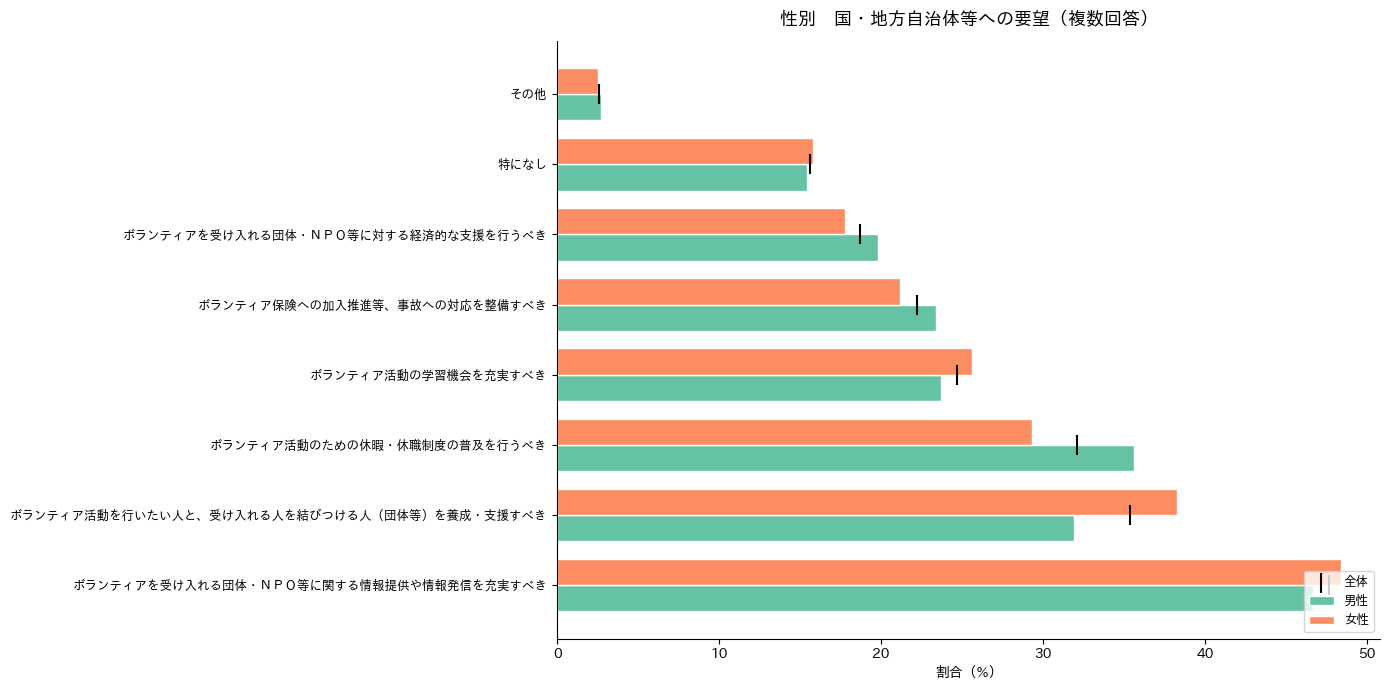

In [34]:
plot_multi_grouped(df65, cols65,
                   '性別　国・地方自治体等への要望（複数回答）',
                   top_n=8, figsize=(14, 7))


### 7.4 関心別（図表2-70）

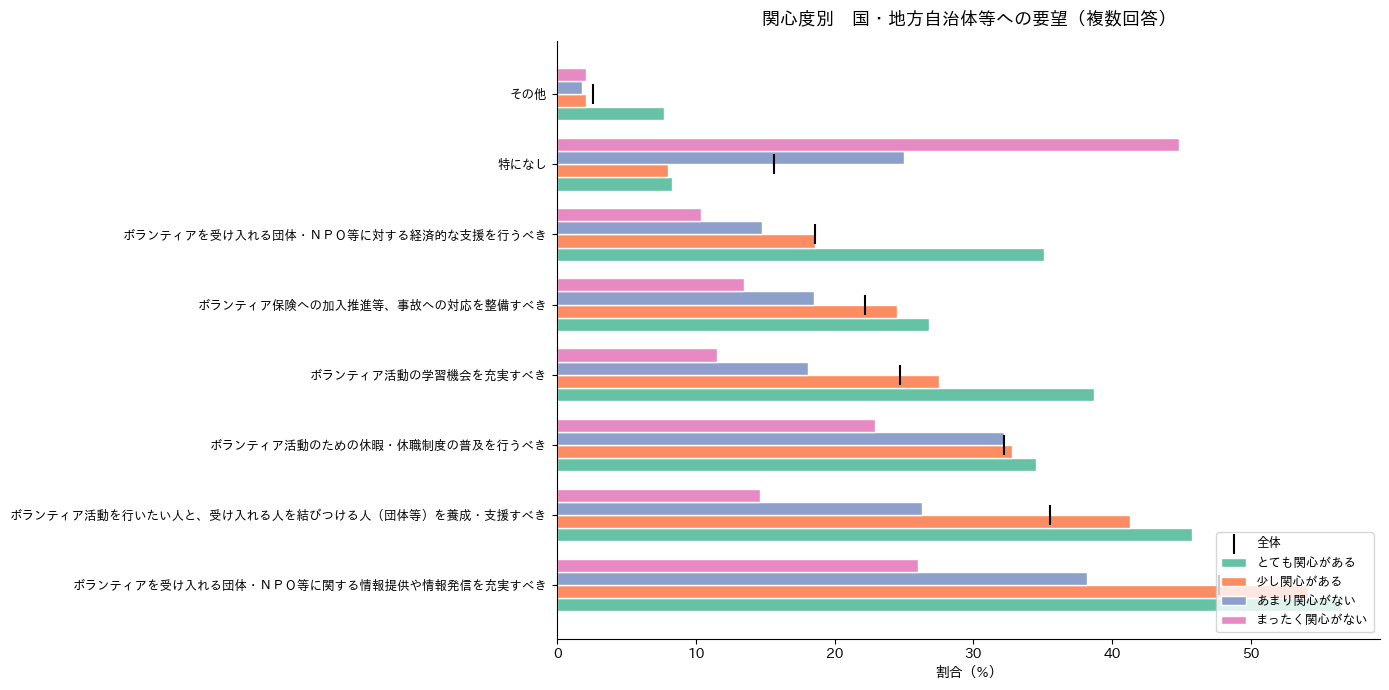

In [35]:
df70, _ = load_sheet('2-70')
cols70 = dcols(df70)
plot_multi_grouped(df70, cols70,
                   '関心度別　国・地方自治体等への要望（複数回答）',
                   top_n=8, figsize=(14, 7))


### 7.5 考察

#### データから読み取れること

- **要望 Top（全体）**：
  ①ボランティアを受け入れる団体・NPO等の情報提供・情報発信の充実
  ②ボランティア活動を行いたい人と受け入れる人を結びつける人材・団体の養成・支援
  ③ボランティア休暇・奨励制度の普及
  **「情報提供」「マッチング」「職場制度」** が三本柱
- **年齢別**：
  若年層（20〜30代）：「ボランティア休暇・奨励制度の普及」が相対的に高い（職場制度改革への期待）
  高齢層（60代）：「情報提供・発信の充実」が高く、情報へのアクセス改善を求める
- **要望と妨げの対応関係**：
  Section 6の妨げ要因Top3（時間・きっかけ・情報）に対応して、
  要望でも「情報充実」「マッチング」「休暇制度」が上位に来ており、**課題認識と要望が整合している**

#### 政策的示唆

現役世代向けには企業のボランティア休暇制度の導入促進が効果的。
情報弱者（高齢層・地方在住者）向けには自治体窓口や地域コーディネーターの拡充が必要。
NPO・市民活動団体の情報発信力強化への補助金・支援制度の整備も求められている。


---
## 8. ボランティア活動経験と寄附行動のクロス分析

図表2-71〜2-83は「ボランティア活動経験あり / なし」を軸にしたクロス集計。
ここではボランティア経験が寄附行動に与える影響を中心に分析する。


### 8.1 経験別　寄附経験の有無（図表2-73）

            n  寄附をしたことがある  寄附をしたことがない
グループ                                 
全体       1637        54.2        45.8
したことがある   437        73.7        26.3
したことがない  1200        47.1        52.9


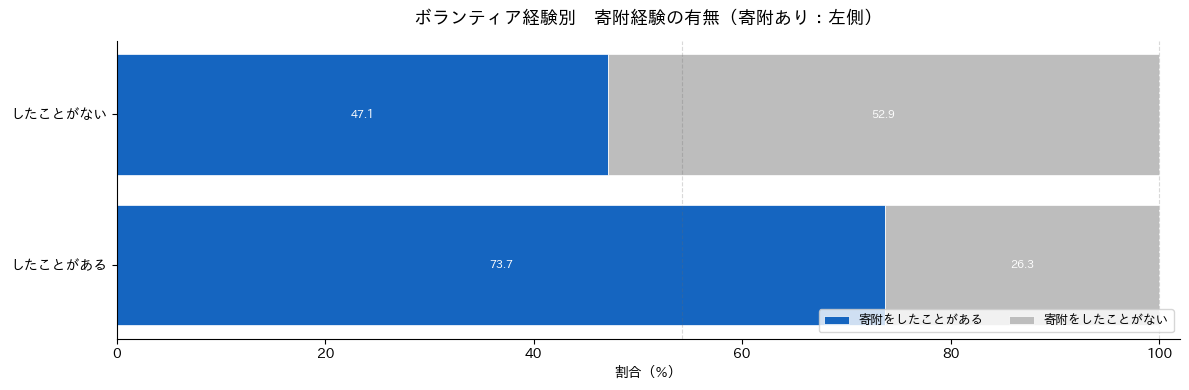

In [36]:
df73, _ = load_sheet('2-73')
print(df73.set_index('グループ').to_string())
plot_stacked(df73, dcols(df73),
             'ボランティア経験別　寄附経験の有無（寄附あり：左側）',
             colors=['#1565C0', '#BDBDBD'], figsize=(12, 4))


### 8.2 経験別　寄附方法（図表2-75）

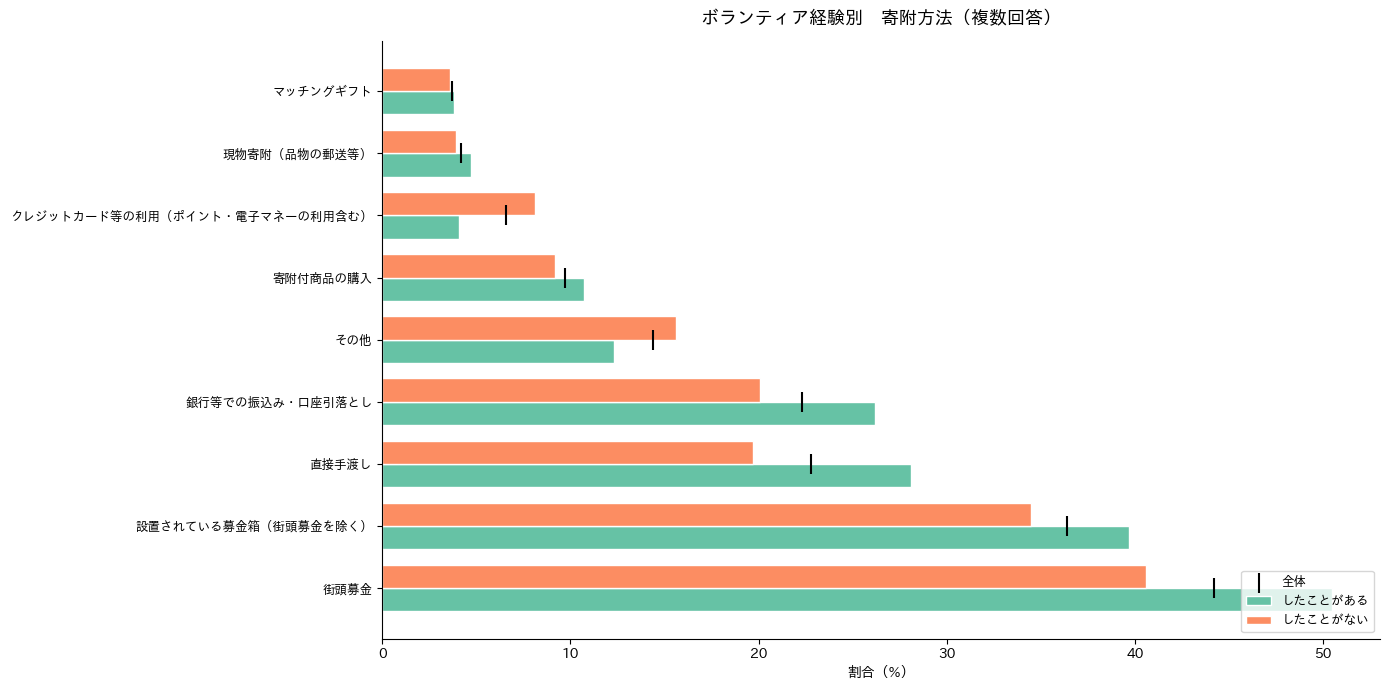

In [37]:
df75, _ = load_sheet('2-75')
cols75 = dcols(df75)
plot_multi_grouped(df75, cols75,
                   'ボランティア経験別　寄附方法（複数回答）',
                   top_n=9, figsize=(14, 7))


### 8.3 経験別　寄附をした相手（図表2-76）

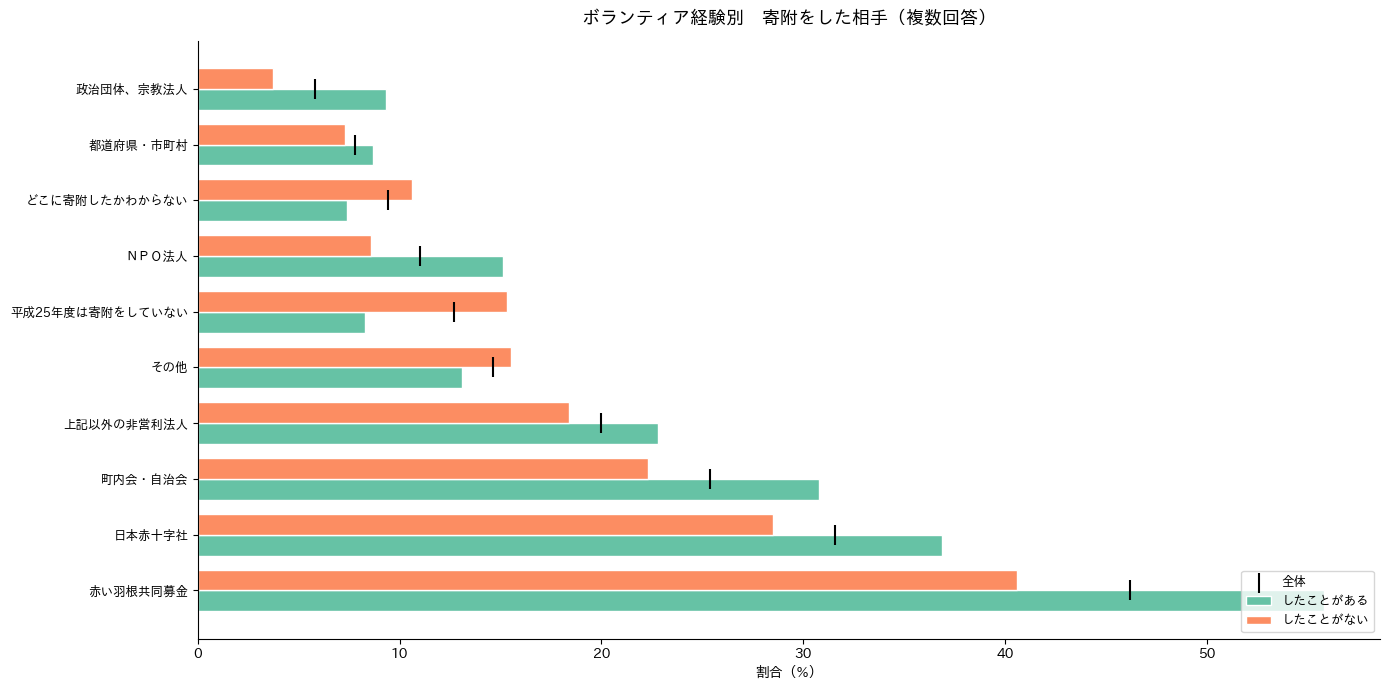

In [38]:
df76, _ = load_sheet('2-76')
cols76 = dcols(df76)
plot_multi_grouped(df76, cols76,
                   'ボランティア経験別　寄附をした相手（複数回答）',
                   top_n=10, figsize=(14, 7))


### 8.4 経験別　寄附理由（図表2-78）

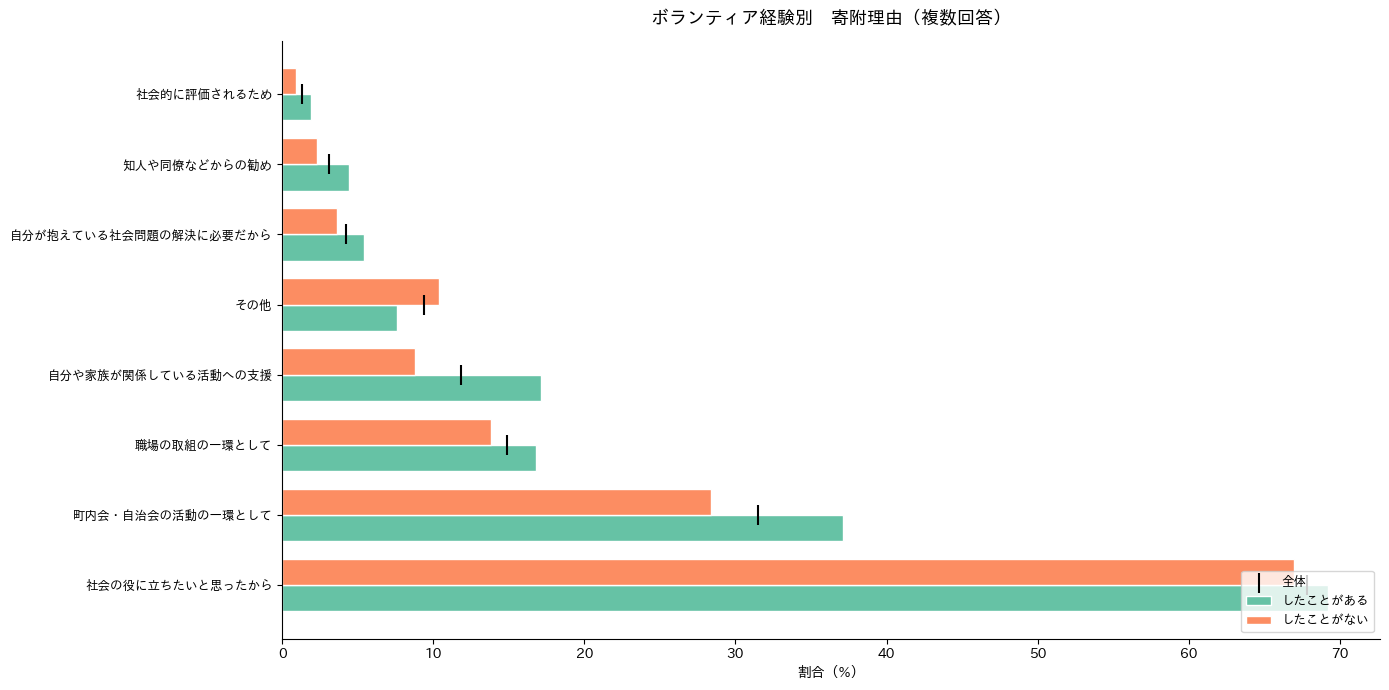

In [39]:
df78, _ = load_sheet('2-78')
cols78 = dcols(df78)
plot_multi_grouped(df78, cols78,
                   'ボランティア経験別　寄附理由（複数回答）',
                   top_n=8, figsize=(14, 7))


### 8.5 経験別　参加分野（図表2-71）

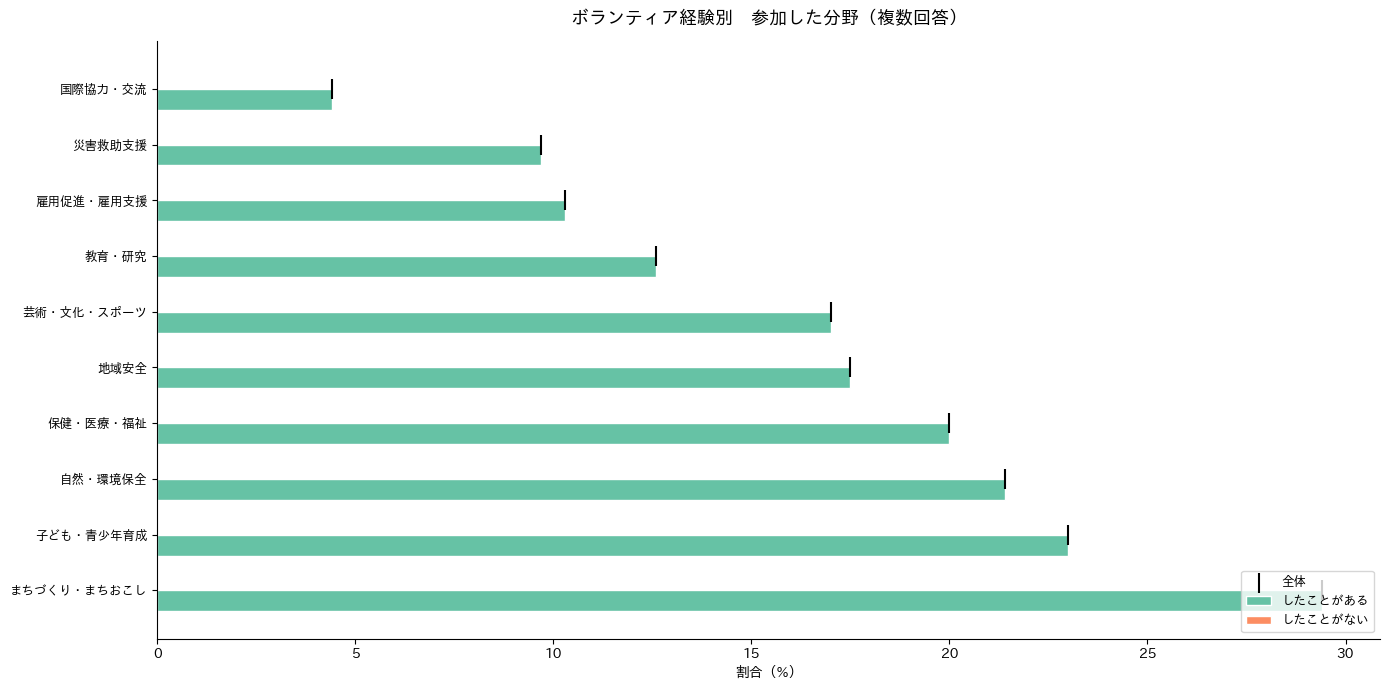

In [40]:
df71, _ = load_sheet('2-71')
cols71 = dcols(df71)
field_cols71 = [c for c in cols71 if '参加していない' not in c and 'その他' not in c]
plot_multi_grouped(df71, field_cols71,
                   'ボランティア経験別　参加した分野（複数回答）',
                   top_n=10, figsize=(14, 7))


### 8.6 経験別　国・地方自治体への要望（図表2-81）

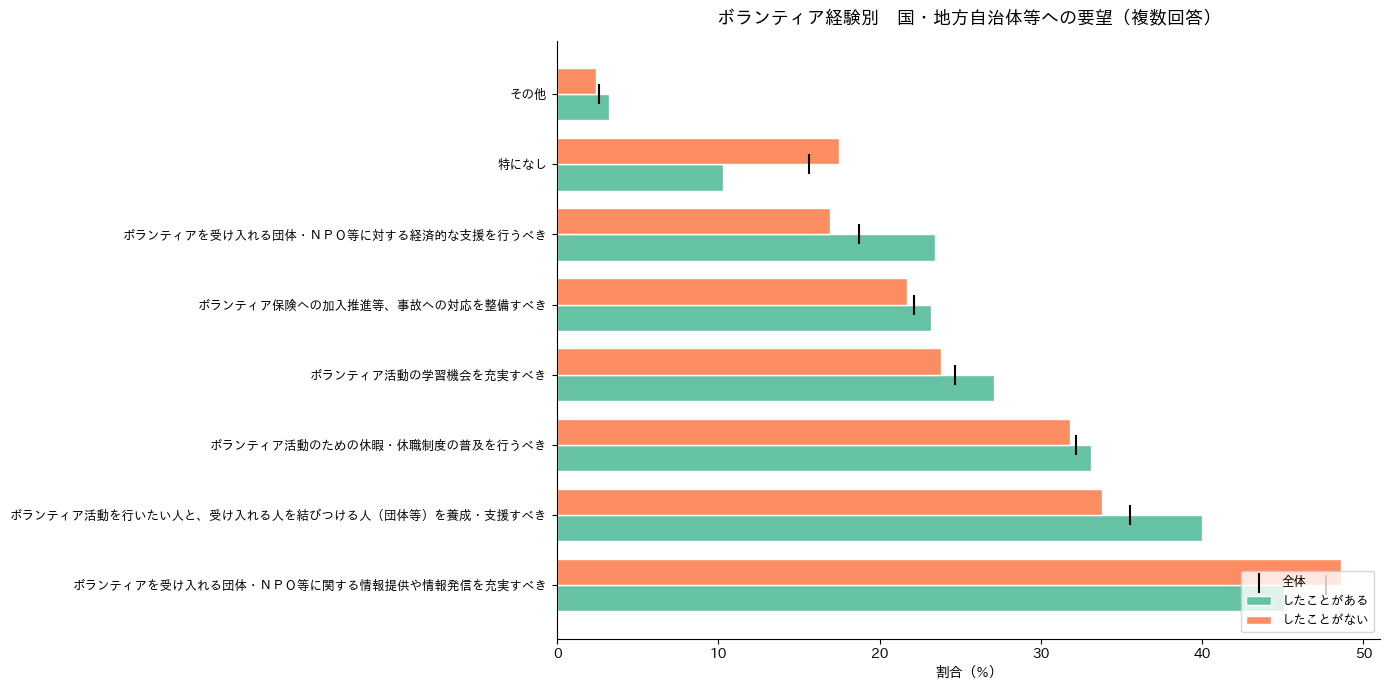

In [41]:
df81, _ = load_sheet('2-81')
cols81 = dcols(df81)
plot_multi_grouped(df81, cols81,
                   'ボランティア経験別　国・地方自治体等への要望（複数回答）',
                   top_n=8, figsize=(14, 7))


### 8.7 参加の妨げ別　寄附妨げとなる要因（図表2-79）

グループ: ['全体', '保健・医療・福祉', '教育・研究', 'まちづくり・まちおこし', '芸術・文化・スポーツ', '自然・環境保全', '災害救助支援', '地域安全', '人権・平和', '国際協力・交流', '子ども・青少年育成', '雇用促進・雇用支援', '平成25年度は、ボランティア活動に参加していない', 'その他']


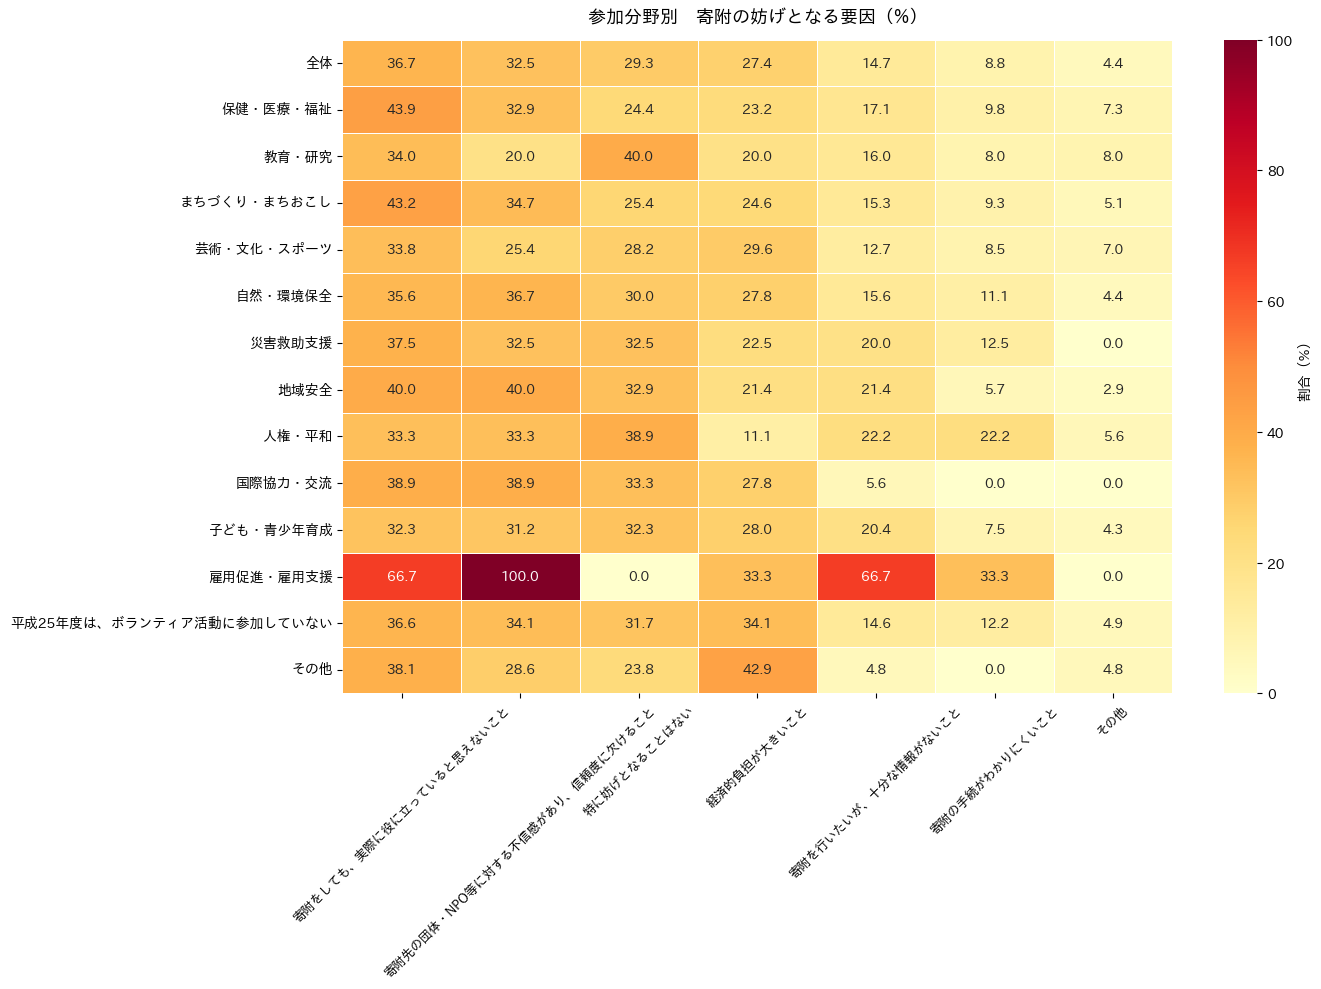

In [42]:
df79, _ = load_sheet('2-79')
cols79 = dcols(df79)
print(f"グループ: {df79['グループ'].tolist()}")
plot_heatmap(df79, cols79,
             '参加分野別　寄附の妨げとなる要因（%）',
             top_n=7, figsize=(14, 10))


### 8.8 考察

#### データから読み取れること（数値）

| 指標 | ボランティア経験あり | ボランティア経験なし |
|------|---------------------|---------------------|
| 寄附経験あり | **73.7%** | 47.1% |
| 寄附経験なし | 26.3% | 52.9% |

**ボランティア経験者の寄附率は非経験者を26ポイント以上上回る。**
これは最も重要な知見の一つであり、両者の相互促進関係を示している。

- **寄附方法の違い**：
  経験者は「銀行振込・口座引き落とし」「NPO等への直接振込」が多く、
  非経験者は「街頭募金」「コンビニ・スーパーの釣り銭募金」など受動的・即席的な方法が相対的に多い
  → 経験者は特定団体との継続的関係を持ち、より積極的・計画的に寄附する傾向がある
- **寄附先の違い**：
  経験者は「NPO法人」「社会福祉協議会」など市民社会組織への直接寄附が多く、
  非経験者は「共同募金」「学校・教育機関」への寄附が相対的に多い
- **寄附理由**：
  経験者・非経験者ともに「社会の役に立ちたい」が1位だが、
  経験者は「活動している団体・組織を支援したい」が高く、
  **ボランティア活動を通じた団体との関係性が寄附につながるルート** が存在することを示す

#### 外部情報との照合 ※参考情報（Web検索による）

日本ファンドレイジング協会「寄付白書」（2015年版）によると、
ボランティア活動参加者の寄附率は非参加者の約2〜3倍高く、
「ボランティア×寄附の善循環」モデルの重要性が指摘されている。
本データはこれを定量的に裏付けている。
また、欧米では「Time donation（時間的寄附）→ Money donation（金銭的寄附）」
というルートが市民社会形成の基盤として研究されており（Putnam, 2000）、
日本でも同様のパターンが見られることが本データから確認できる。


---
## 9. 総合考察

### 9.1 主要知見サマリー

| 分析テーマ | 主な知見 |
|-----------|---------|
| ボランティア関心 | 約62%が関心を持つが経験率は約27%。関心-行動ギャップが約35ポイント |
| 参加属性 | 60代・高収入・主婦・退職者層で参加率高。現役世代（20〜40代）で低 |
| 参加分野 | まちづくり（29%）・子ども育成（23%）・自然環境保全（21%）が上位 |
| 性別分野差 | 男性=自然・地域安全、女性=保健・医療・子育て と明確に分かれる |
| 参加理由 | 「社会の役に立ちたい」「自己啓発」など内発的動機が主 |
| 参加の妨げ | 「時間なし」「きっかけなし」「情報なし」が三大障壁。女性は家事・育児も |
| 国への要望 | 情報提供充実・マッチング支援・ボランティア休暇制度の普及が上位 |
| ボランティア×寄附 | 経験者の寄附率73.7% vs 非経験者47.1%。26ポイントの大きな差 |

### 9.2 政策的示唆

**① 現役世代（20〜40代）向け：時間的障壁の解消**
- 企業のボランティア休暇・ボランティア奨励制度の普及促進（税制上の優遇等）
- 短時間・単発・オンライン参加が可能なマイクロボランティアの拡充
- 職場単位のチームボランティア活動の奨励（外発的きっかけの提供）

**② 情報・マッチング環境の整備**
- 地域ボランティアコーディネーターの養成・配置
- 参加者と受入れ団体をつなぐデジタルプラットフォームの整備
- 高齢層向けには紙・窓口ベースの情報提供も必要

**③ 女性の社会参加促進との連動**
- 家事・育児負担が参加の大きな壁となっており、
  子連れ参加可能なプログラムや保育サポート付きボランティアの整備が有効

**④ ボランティア→寄附の善循環の促進**
- ボランティア参加がその後の継続的寄附につながることが示されたため、
  まず「体験参加」のハードルを下げることが寄附文化の醸成にも有効

### 9.3 データの限界と留意点

- 本ファイルには **図表2-29〜2-83のみ収録**。基本単純集計（2-1〜2-28）・
  寄附詳細（2-84〜2-162）は本分析には含まれていない
- すべての数値は **パーセンテージ**。絶対数は n= から算出可能
- 調査時点は **平成26年度（2014年）** であり、
  スマートフォンの普及・コロナ禍・SDGs普及等の社会変化を踏まえた解釈が必要
- 寄附・NPO関連クロス（2-84〜2-162）の分析は本ファイルの対象外のため、
  寄附行動の全体像を把握するには追加データが必要

### 9.4 今後の分析への提言

- 基本単純集計（2-1〜2-28）と組み合わせることで、
  回答者プロフィールの全体像と各設問の単純集計を確認できる
- 経年比較（平成18年度調査との比較等）により、
  ボランティア参加率・寄附率のトレンド分析が可能
- 本データと公的統計（社会生活基本調査、寄付白書等）のクロス参照により、
  標本の代表性・一般化可能性をより厳密に検証することが望ましい
